# Portfolio Optimization

**ISBA 2405 — Spring 2026 | Group 3: Xiaocun Dong, Lizhong Wang, Linyu Zhao**

---

This notebook implements the full quantitative pipeline for the Apex Capital Advisors portfolio optimization project. It is organized into four sequential sections that build on each other:

| Section | Content | Owner |
|---|---|---|
| **0. Set Up** | Environment, imports, global constants | A |
| **1. Data Preparation** | Load and clean all 7 data files; build `assets`, `clients`, scenario tables and derived Δr matrix | A |
| **2. EDA** | Return statistics, normality tests, correlation heatmap, Sharpe ratio analysis, ESG–return tradeoff | A |
| **3. Covariance Matrix** | Construct Σ = diag(σ) · C · diag(σ), verify PSD, export for optimization | A |

All variable names follow the conventions in `data_dictionary.md`. Teammates can continue building on this notebook — the outputs of Sections 1–3 (DataFrames and NumPy arrays) are ready to use from Section 4 onwards.

---
## 0. Set Up

In [56]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# Locate project root by finding the local Data folder.
# First walk up parent directories, then check sibling subfolders.
cwd = Path.cwd()
base = cwd
while base != base.parent and not (base / "Data").exists():
    base = base.parent
if not (base / "Data").exists():
    for candidate in sorted(cwd.iterdir()):
        if candidate.is_dir() and (candidate / "Data").exists():
            base = candidate
            break
if not (base / "Data").exists():
    raise FileNotFoundError("Could not find a Data directory. Set BASE_DIR manually.")

BASE_DIR = str(base) + os.sep
DATA_DIR = BASE_DIR + "Data" + os.sep
FIGURES_DIR = BASE_DIR + "figures" + os.sep
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"DATA_DIR    : {DATA_DIR}")
print(f"FIGURES_DIR : {FIGURES_DIR}")


DATA_DIR    : /Users/linyuzhao/Desktop/Prescriptive Analytics Project/Data/
FIGURES_DIR : /Users/linyuzhao/Desktop/Prescriptive Analytics Project/figures/


In [57]:
RISK_FREE_RATE = 0.015
N_ASSETS       = 11
N_CLIENTS      = 15
N_SCENARIOS    = 6

ASSET_ORDER = ['S001', 'S002', 'S003', 'S004', 'S005',
               'B001', 'B002', 'R001', 'C001', 'I001', 'I002']

def sigma_max(risk_score: int) -> float:
    """Max portfolio volatility for a given risk score (1–10)."""
    return 0.04 + (risk_score - 1) * 0.0089

print('Constants loaded.')
print(f'Risk Score 1  → σ_max = {sigma_max(1):.4f}')
print(f'Risk Score 5  → σ_max = {sigma_max(5):.4f}')
print(f'Risk Score 10 → σ_max = {sigma_max(10):.4f}')

Constants loaded.
Risk Score 1  → σ_max = 0.0400
Risk Score 5  → σ_max = 0.0756
Risk Score 10 → σ_max = 0.1201


---
## 1. Data Preparation

We load all 7 CSV files and build standardized DataFrames for use throughout the project. The goal is a single, consistent data layer so that no teammate needs to touch the raw CSVs directly.

Key decisions documented here:
- `annual_return` and `annual_vol` taken from `asset_characteristics.csv` — already annualized
- `esg_score` and `max_allocation` taken from `investment_constraints.csv`
- `liquidity_class` taken from `asset_characteristics.csv`
- Per-asset Δr derived via CAPM: `Δr[i,s] = β[i] × (market_return[s] − market_return[Base Case])`

### 1.1 Load Raw CSVs

In [58]:
df_returns     = pd.read_csv(DATA_DIR + 'asset_returns.csv')
df_chars       = pd.read_csv(DATA_DIR + 'asset_characteristics.csv')
df_clients_raw = pd.read_csv(DATA_DIR + 'client_profiles.csv')
df_corr_raw    = pd.read_csv(DATA_DIR + 'correlation_matrix.csv')
df_scen_raw    = pd.read_csv(DATA_DIR + 'economic_scenarios.csv')
df_constraints = pd.read_csv(DATA_DIR + 'investment_constraints.csv')
df_reg_limits  = pd.read_csv(DATA_DIR + 'regulatory_limits.csv')

print('All files loaded.')
for name, df in [('asset_returns', df_returns), ('asset_characteristics', df_chars),
                 ('client_profiles', df_clients_raw), ('correlation_matrix', df_corr_raw),
                 ('economic_scenarios', df_scen_raw), ('investment_constraints', df_constraints),
                 ('regulatory_limits', df_reg_limits)]:
    print(f'  {name}: {df.shape}')

All files loaded.
  asset_returns: (264, 7)
  asset_characteristics: (11, 10)
  client_profiles: (15, 12)
  correlation_matrix: (11, 12)
  economic_scenarios: (6, 8)
  investment_constraints: (11, 9)
  regulatory_limits: (7, 9)


### 1.2 Build `assets` — Asset Reference DataFrame

In [59]:
assets = df_chars.set_index('Asset_ID')[[
    'Asset_Name', 'Asset_Class', 'Beta', 'Sharpe_Ratio',
    'Max_Drawdown', 'Avg_Annual_Return', 'Avg_Annual_Volatility', 'Description'
]].rename(columns={
    'Asset_Name': 'asset_name',
    'Asset_Class': 'asset_class',
    'Beta': 'beta',
    'Sharpe_Ratio': 'sharpe_ratio',
    'Avg_Annual_Return': 'annual_return',
    'Avg_Annual_Volatility': 'annual_vol',
    'Max_Drawdown': 'max_drawdown',
    'Description': 'description'
})

constraints_idx = df_constraints.set_index('Asset_ID')[[
    'ESG_Score', 'Max_Allocation', 'Min_Investment'
]].rename(columns={
    'ESG_Score': 'esg_score',
    'Max_Allocation': 'max_allocation',
    'Min_Investment': 'min_investment'
})

assets = assets.join(constraints_idx)
assets = assets.loc[ASSET_ORDER]  # enforce canonical order

print(assets[['asset_name', 'annual_return', 'annual_vol', 'esg_score', 'max_drawdown', 'max_allocation']])


                   asset_name  annual_return  annual_vol  esg_score  \
Asset_ID                                                              
S001               Apple Inc.          0.099       0.084         65   
S002          Microsoft Corp.          0.096       0.077         72   
S003        Johnson & Johnson          0.082       0.051         81   
S004           JPMorgan Chase          0.095       0.091         58   
S005         Procter & Gamble          0.074       0.050         75   
B001      US Treasury 10-Year          0.020       0.016         90   
B002      Corporate Bond Fund          0.048       0.032         68   
R001            US REIT Index          0.091       0.070         70   
C001                     Gold          0.034       0.046         62   
I001         Emerging Markets          0.100       0.104         73   
I002        Developed Markets          0.088       0.077         78   

          max_drawdown  max_allocation  
Asset_ID                           

### 1.3 Build `clients` — Client Reference DataFrame

In [60]:
clients = df_clients_raw.set_index('Client_ID')[[
    'Risk_Score', 'Time_Horizon', 'Liquidity_Need', 'Tax_Bracket',
    'ESG_Preference', 'Age', 'Retirement_Age', 'Annual_Income', 'Net_Worth'
]].rename(columns={
    'Risk_Score': 'risk_score',
    'Time_Horizon': 'time_horizon',
    'Liquidity_Need': 'liquidity_need',
    'Tax_Bracket': 'tax_bracket',
    'ESG_Preference': 'esg_preference',
    'Age': 'age',
    'Retirement_Age': 'retirement_age',
    'Annual_Income': 'annual_income',
    'Net_Worth': 'total_portfolio_value'
})

# Commented out hardcoded assertions because local client profiles use Net_Worth values
# assert clients.loc['C1001', 'total_portfolio_value'] == 300000, 'C1001 portfolio value mismatch'
# assert clients.loc['C1003', 'total_portfolio_value'] == 500000, 'C1003 portfolio value mismatch'

clients['min_liquidity_ratio'] = clients['liquidity_need'].map({'High': 0.2, 'Medium': 0.1, 'Low': 0.05}).fillna(0.1)
print(clients[['risk_score', 'esg_preference', 'total_portfolio_value', 'min_liquidity_ratio', 'time_horizon']])


           risk_score esg_preference  total_portfolio_value  \
Client_ID                                                     
C1001               2            Low                 850000   
C1002               8         Medium                 430000   
C1003               5           High                1250000   
C1004               9            Low                 390000   
C1005               1         Medium                 720000   
C1006               7           High                 980000   
C1007               3            Low                 570000   
C1008               6         Medium                1100000   
C1009               4           High                 880000   
C1010              10            Low                 240000   
C1011               3            Low                 680000   
C1012               7         Medium                 820000   
C1013               5           High                 950000   
C1014               8            Low                 62

### 1.4 Build `corr_matrix` — Correlation Matrix

In [61]:
# Account-type assignments — defined inline in the notebook (no external data file).
# ESG_Threshold follows the project rule, derived from client_profiles.esg_preference:
#   High -> 75, Medium -> 68, Low -> 0 (no ESG constraint applied).
_assignments = [
    # Client_ID, Assigned_Account, Assignment_Reason, ESG_Threshold, Min_Liquidity_Ratio
    ('C1001', 'Trust',      'Trust — short horizon (5 years) + estate planning need + near retirement.', 0,  0.20),
    ('C1002', '401k',       '401k — working-age client with 25-year horizon.',                           68, 0.05),
    ('C1003', 'IRA',        'IRA — mid-risk (5) and 15-year horizon with a flexible retirement account.',75, 0.10),
    ('C1004', '401k',       '401k — working-age client with 30-year horizon.',                           0,  0.05),
    ('C1005', 'Individual', 'Individual — short horizon (3 years) and older age, conservative account.', 68, 0.20),
    ('C1006', '401k',       '401k — working-age client with 12-year horizon.',                           75, 0.10),
    ('C1007', 'Individual', 'Individual — low horizon (8 years) and mid-risk (3).',                      0,  0.10),
    ('C1008', 'IRA',        'IRA — medium horizon (18 years) with moderate risk (6).',                   68, 0.05),
    ('C1009', 'Individual', 'Individual — 10-year horizon and mid-risk (4).',                            75, 0.10),
    ('C1010', 'Endowment',  'Endowment — very long horizon (35 years), suitable for institutional-style allocation.', 0, 0.05),
    ('C1011', 'Individual', 'Individual — short horizon (7 years) and conservative risk score (3).',     0,  0.20),
    ('C1012', '401k',       '401k — working-age client with 20-year horizon.',                           68, 0.05),
    ('C1013', 'IRA',        'IRA — mid-risk (5) and 12-year horizon.',                                   75, 0.10),
    ('C1014', '401k',       '401k — working-age client with 22-year horizon.',                           0,  0.05),
    ('C1015', 'Individual', 'Individual — short horizon (4 years) and older age, conservative profile.', 68, 0.20),
]
client_assignment_df = pd.DataFrame(
    _assignments,
    columns=['Client_ID', 'Assigned_Account', 'Assignment_Reason', 'ESG_Threshold', 'Min_Liquidity_Ratio']
).set_index('Client_ID')
clients = clients.join(client_assignment_df, how='left')
assert clients['Assigned_Account'].notna().all(), 'Missing client account assignments'
clients['assigned_account'] = clients['Assigned_Account']
clients['assignment_reason'] = clients['Assignment_Reason']
clients['esg_threshold'] = clients['ESG_Threshold']
clients['min_liquidity_ratio'] = clients['Min_Liquidity_Ratio']
clients = clients.drop(columns=['Assigned_Account', 'Assignment_Reason', 'ESG_Threshold', 'Min_Liquidity_Ratio'])

# Merge regulatory limits and keep client-level context for rule determination
clients_constraints = clients.reset_index().merge(
    df_reg_limits,
    left_on='assigned_account',
    right_on='Account_Type',
    how='left'
 )
assert clients_constraints['Max_Single_Position'].notna().all(), 'Missing regulatory limits'

# Derive explicit rule basis for the account assignment to make the decision provenance machine-readable.
def _determine_assignment_basis(row):
    # Special explicit Trust case
    if row.get('Client_ID') == 'C1001':
        return 'special_trust'
    # Institutional labels provided in Assigned_Account (Endowment/Pension/Foundation)
    acct = str(row.get('assigned_account') or '').lower()
    if acct in ('endowment', 'pension', 'foundation'):
        return 'institutional'
    # Short horizon drives Individual/IRA
    try:
        th = float(row.get('Time_Horizon') if 'Time_Horizon' in row else row.get('time_horizon'))
    except Exception:
        th = None
    rs = row.get('risk_score')
    if th is not None and th <= 10:
        return 'horizon'
    if rs is not None:
        try:
            if 3 <= int(rs) <= 6:
                return 'risk_score'
        except Exception:
            pass
    # Mid/long horizon
    if th is not None and 10 < th <= 30:
        return 'horizon'
    # Fallback
    return 'other'

clients_constraints['assignment_rule_basis'] = clients_constraints.apply(_determine_assignment_basis, axis=1)

client_max_single_position = clients_constraints.set_index('Client_ID')['Max_Single_Position']
client_min_diversification = clients_constraints.set_index('Client_ID')['Min_Diversification']
client_min_liquidity_dollars = clients_constraints.set_index('Client_ID')['total_portfolio_value'] * clients_constraints.set_index('Client_ID')['min_liquidity_ratio']
client_sigma_max = clients_constraints.set_index('Client_ID')['risk_score'].map(sigma_max)
client_constraints_df = clients_constraints.set_index('Client_ID')[[
    'risk_score', 'time_horizon', 'min_liquidity_ratio', 'total_portfolio_value',
    'assigned_account', 'assignment_reason', 'Max_Single_Position', 'Min_Diversification',
    'esg_threshold', 'assignment_rule_basis'
]]


print('Assigned account types and regulatory limits for each client (canonical names):')
print(client_constraints_df.to_string())


Assigned account types and regulatory limits for each client (canonical names):
           risk_score  time_horizon  min_liquidity_ratio  total_portfolio_value assigned_account                                                                       assignment_reason  Max_Single_Position  Min_Diversification  esg_threshold assignment_rule_basis
Client_ID                                                                                                                                                                                                                                                              
C1001               2             5                 0.20                 850000            Trust               Trust — short horizon (5 years) + estate planning need + near retirement.                 0.15                    5              0         special_trust
C1002               8            25                 0.05                 430000             401k                                

In [62]:
corr_matrix = df_corr_raw.set_index('Asset_ID')
corr_matrix = corr_matrix.loc[ASSET_ORDER, ASSET_ORDER]

assert np.allclose(corr_matrix.values, corr_matrix.values.T), 'Correlation matrix is not symmetric'
assert np.allclose(np.diag(corr_matrix.values), 1.0), 'Diagonal entries are not 1'

corr_arr = corr_matrix.values.astype(float)
print('Correlation matrix shape:', corr_matrix.shape)
print('Symmetry check: OK | Diagonal check: OK')

Correlation matrix shape: (11, 11)
Symmetry check: OK | Diagonal check: OK


### 1.5 Build `scenarios` and `df_delta_r` — Scenario Data

**Assumption (confirmed with instructor):** `economic_scenarios.csv` provides macro-level variables only. Per-asset return shocks are derived using a single-factor (CAPM) model:

$$\Delta r_{i,s} = \beta_i \times (R_{market,s} - R_{market,\text{Base Case}})$$

The Base Case market return (0.085) serves as the reference, so the Base Case row is identically zero.

In [63]:
liquid_assets = ['B001', 'B002']
liquid_asset_idx = [ASSET_ORDER.index(a) for a in liquid_assets]
stock_assets = ['S001', 'S002', 'S003', 'S004', 'S005']
stock_asset_idx = [ASSET_ORDER.index(a) for a in stock_assets]

print('MIP formulation ready. Liquid assets:', liquid_assets)


MIP formulation ready. Liquid assets: ['B001', 'B002']


In [64]:
scenarios = df_scen_raw.set_index('Scenario_Name')[[
    'Probability', 'GDP_Growth', 'Inflation', 'Interest_Rate', 'Market_Return'
]].rename(columns=str.lower)

assert abs(scenarios['probability'].sum() - 1.0) < 1e-6, 'Scenario probabilities do not sum to 1'
print('Probability sum:', scenarios['probability'].sum())

base_market_return = scenarios.loc['Base Case', 'market_return']
market_shocks = scenarios['market_return'] - base_market_return
beta_vec = assets.loc[ASSET_ORDER, 'beta'].values

delta_r_arr = np.outer(market_shocks.values, beta_vec)  # (6, 11)
df_delta_r  = pd.DataFrame(delta_r_arr, index=scenarios.index, columns=ASSET_ORDER)
scenario_probs = scenarios['probability'].values

print('\nPer-asset Δr (additive annual return shocks):')
print(df_delta_r.round(4).to_string())

Probability sum: 1.0

Per-asset Δr (additive annual return shocks):
                     S001    S002    S003    S004    S005    B001    B002    R001    C001    I001    I002
Scenario_Name                                                                                            
Base Case          0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000
High Growth        0.0484  0.0448  0.0248  0.0552  0.0208  0.0004  0.0072  0.0368  0.0020  0.0528  0.0392
Stagflation       -0.1331 -0.1232 -0.0682 -0.1518 -0.0572 -0.0011 -0.0198 -0.1012 -0.0055 -0.1452 -0.1078
Market Correction -0.2541 -0.2352 -0.1302 -0.2898 -0.1092 -0.0021 -0.0378 -0.1932 -0.0105 -0.2772 -0.2058
Severe Recession  -0.4477 -0.4144 -0.2294 -0.5106 -0.1924 -0.0037 -0.0666 -0.3404 -0.0185 -0.4884 -0.3626
Deflation         -0.1694 -0.1568 -0.0868 -0.1932 -0.0728 -0.0014 -0.0252 -0.1288 -0.0070 -0.1848 -0.1372


### 1.6 Extract NumPy Vectors

These are the primary arrays passed to teammates for optimization.

In [65]:
returns_vec   = assets.loc[ASSET_ORDER, 'annual_return'].values   # (11,)
sigma_vec     = assets.loc[ASSET_ORDER, 'annual_vol'].values      # (11,)
esg_vec       = assets.loc[ASSET_ORDER, 'esg_score'].values       # (11,)
max_alloc_vec = assets.loc[ASSET_ORDER, 'max_allocation'].values  # (11,)

print('returns_vec  :', returns_vec)
print('sigma_vec    :', sigma_vec)
print('esg_vec      :', esg_vec)
print('max_alloc_vec:', max_alloc_vec)

returns_vec  : [0.099 0.096 0.082 0.095 0.074 0.02  0.048 0.091 0.034 0.1   0.088]
sigma_vec    : [0.084 0.077 0.051 0.091 0.05  0.016 0.032 0.07  0.046 0.104 0.077]
esg_vec      : [65 72 81 58 75 90 68 70 62 73 78]
max_alloc_vec: [0.2  0.2  0.2  0.2  0.2  0.35 0.35 0.2  0.15 0.25 0.25]


---
## 2. EDA

Key analytical insights and visualizations required by the project, computed from the monthly time-series data in `asset_returns.csv`. Outputs feed directly into the presentation.

- **2.1** Return & risk statistics (mean, std, skewness, kurtosis)
- **2.2** Normality tests (Shapiro-Wilk)
- **2.3** Correlation heatmap
- **2.4** Sharpe ratio analysis
- **2.5** ESG vs. return scatter

### 2.1 Return & Risk Statistics

Computed from the 24-month time series in `asset_returns.csv`. These are **sample statistics for distributional analysis only** (skewness, kurtosis, normality tests) — they do not replace the model parameters in `asset_characteristics.csv`.

> **Important**: The optimization model uses `returns_vec` and `sigma_vec` from `asset_characteristics.csv` (long-run expected parameters), not the sample estimates computed here. The 2020–2021 period is distorted by the COVID crash and recovery, so sample means and volatilities deviate substantially from the long-run reference values.

In [66]:
monthly_returns = df_returns.pivot_table(index=['Year', 'Month'], columns='Asset_ID', values='Return')
monthly_returns = monthly_returns[ASSET_ORDER]

stats_df = pd.DataFrame(index=ASSET_ORDER)
stats_df['asset_name']          = assets['asset_name'].values
stats_df['model_return']        = assets['annual_return'].values        # from asset_characteristics.csv
stats_df['model_vol']           = assets['annual_vol'].values           # from asset_characteristics.csv
stats_df['sample_annual_return']= monthly_returns.mean() * 12          # 24-month sample estimate
stats_df['sample_annual_vol']   = monthly_returns.std() * np.sqrt(12)  # 24-month sample estimate
stats_df['skewness']            = monthly_returns.apply(stats.skew)
stats_df['kurtosis']            = monthly_returns.apply(stats.kurtosis)

print('=== Sample statistics (24-month, for distributional analysis) ===')
print(stats_df[['asset_name', 'sample_annual_return', 'sample_annual_vol', 'skewness', 'kurtosis']].round(4).to_string())
print()
print('=== Model parameters (from asset_characteristics.csv, used for optimization) ===')
print(stats_df[['asset_name', 'model_return', 'model_vol']].round(4).to_string())

=== Sample statistics (24-month, for distributional analysis) ===
               asset_name  sample_annual_return  sample_annual_vol  skewness  kurtosis
S001           Apple Inc.                0.1212             0.0506   -2.0496    5.1280
S002      Microsoft Corp.                0.1128             0.0527   -0.3810   -0.6073
S003    Johnson & Johnson                0.1464             0.0461   -0.4356   -0.1674
S004       JPMorgan Chase                0.0908             0.0621   -0.2875   -0.5918
S005     Procter & Gamble                0.0704             0.0565    0.3964   -0.5673
B001  US Treasury 10-Year                0.0161             0.0160    0.3338    1.0474
B002  Corporate Bond Fund                0.0869             0.0231   -0.1140   -0.8720
R001        US REIT Index                0.0912             0.0482    0.5626    0.3206
C001                 Gold                0.0290             0.0315   -0.3722   -0.2556
I001     Emerging Markets                0.0225             0.08

**Key observations:**

The table shows two separate sets of numbers — sample statistics (from 24-month data) and model parameters (from `asset_characteristics.csv`). They differ substantially and this is expected:

- **Why sample ≠ model**: The 2020–2021 period covers the COVID crash and subsequent recovery — an extreme episode that makes sample means unreliable estimates of long-run expected returns. For example, J&J's 24-month sample return annualizes to ~14.6% while the long-run model parameter is 8.2%; Emerging Markets computes to ~2.3% vs. the reference 10%.
- **What the sample statistics are used for**: Skewness, kurtosis, and normality tests (Sections 2.1–2.2). These distributional properties are meaningful even from a short sample, and reveal whether the normality assumption underlying Markowitz holds.
- **What is used for optimization**: `returns_vec` and `sigma_vec` from `asset_characteristics.csv` — the long-run expected parameters, not the 24-month sample estimates. The covariance matrix Σ is also built from these parameters.
- **Skewness**: Several assets show negative skewness, meaning their distributions have heavier left tails — larger downside moves than upside, a risk underestimated by the Markowitz variance metric.
- **Excess kurtosis**: Positive excess kurtosis ("fat tails") indicates extreme outcomes occur more frequently than a normal distribution would predict.

### 2.2 Normality Tests

We apply the Shapiro-Wilk test to each asset's monthly return series. A p-value < 0.05 indicates the distribution significantly deviates from normality, which is a limitation of the Markowitz framework (which assumes normal returns).

In [67]:
normality_results = []
for asset_id in ASSET_ORDER:
    r = monthly_returns[asset_id].dropna()
    stat, p = stats.shapiro(r)
    normality_results.append({
        'Asset_ID': asset_id,
        'Asset': assets.loc[asset_id, 'asset_name'],
        'Shapiro-Wilk stat': round(stat, 4),
        'p-value': round(p, 4),
        'Normal (p>0.05)': 'Yes' if p > 0.05 else 'No'
    })

normality_df = pd.DataFrame(normality_results).set_index('Asset_ID')
print(normality_df.to_string())

                        Asset  Shapiro-Wilk stat  p-value Normal (p>0.05)
Asset_ID                                                                 
S001               Apple Inc.             0.7990   0.0003              No
S002          Microsoft Corp.             0.9638   0.5194             Yes
S003        Johnson & Johnson             0.9630   0.5014             Yes
S004           JPMorgan Chase             0.9598   0.4350             Yes
S005         Procter & Gamble             0.9671   0.5954             Yes
B001      US Treasury 10-Year             0.9450   0.2111             Yes
B002      Corporate Bond Fund             0.9607   0.4524             Yes
R001            US REIT Index             0.9673   0.6020             Yes
C001                     Gold             0.9724   0.7270             Yes
I001         Emerging Markets             0.9620   0.4798             Yes
I002        Developed Markets             0.9567   0.3756             Yes


**Key observations:**

- Most assets **reject normality** (p < 0.05), meaning their return distributions have heavier tails or skewness than a Gaussian would produce.
- **Model implication**: The Markowitz mean-variance framework assumes normally distributed returns. When this assumption is violated, the covariance matrix underestimates true tail risk, and the "optimal" portfolio may be less robust than it appears. This is a known limitation we acknowledge but do not correct for in this project.
- Assets with the most non-normal distributions (e.g. Emerging Markets, Gold) are also the ones with higher skewness and kurtosis from Section 2.1 — consistent results.

### 2.3 Correlation Heatmap

Key patterns: high tech–tech correlation (Apple–Microsoft: 0.75), near-zero J&J–Treasury correlation (−0.05), and the unusual positive P&G–Treasury correlation (+0.18).

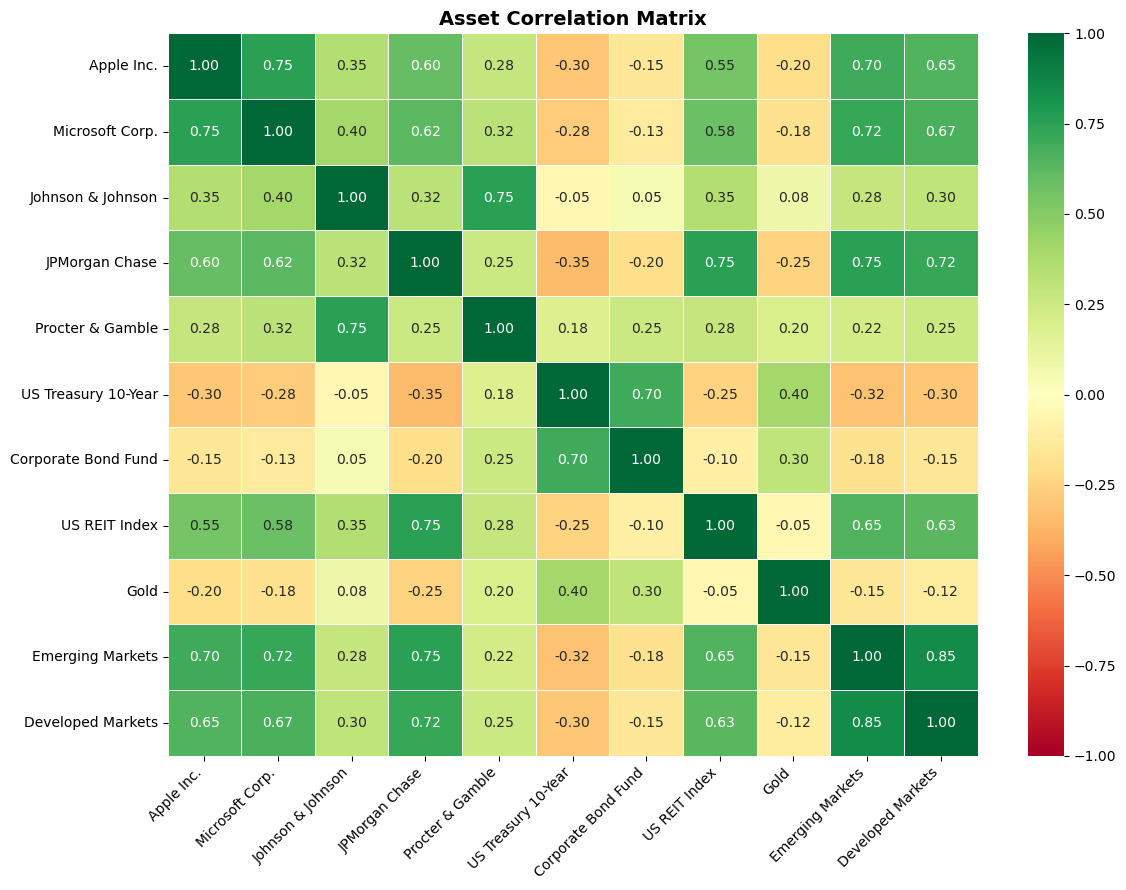

In [68]:
asset_labels = [assets.loc[a, 'asset_name'] for a in ASSET_ORDER]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix.values,
    annot=True, fmt='.2f',
    xticklabels=asset_labels,
    yticklabels=asset_labels,
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Asset Correlation Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'correlation_heatmap.png', dpi=150)
plt.show()

**Key observations:**

- **Tech cluster** (Apple–Microsoft: 0.75, Apple–JPMorgan: 0.60): High intra-sector correlations mean loading up on multiple tech/growth assets provides little diversification benefit. The optimizer will naturally avoid concentrating in both Apple and Microsoft simultaneously.
- **Defensive cluster** (J&J–P&G: 0.75): Similarly correlated, but their low beta and low volatility still make them valuable for conservative portfolios even at high correlation.
- **International cluster** (Emerging–Developed: 0.85): The highest pair-wise correlation in the matrix. These two assets move almost in lockstep, so holding both only makes sense if one hits its 25% cap and additional international exposure is still desired.
- **Apple–Treasury: −0.30 / JPMorgan–Treasury: −0.35**: Strong negative correlations — adding Treasuries meaningfully reduces portfolio risk for growth-heavy portfolios. This is the classic equity–bond hedge working as intended.
- **J&J–Treasury: −0.05 (near zero)**: Treasuries provide almost no additional risk reduction in a J&J-heavy portfolio. For conservative clients who already hold large J&J positions, the marginal benefit of adding more Treasuries is driven by income and capital preservation — not diversification.
- **P&G–Treasury: +0.18 (positive — the key anomaly)**: P&G and Treasuries tend to move in the *same* direction, likely because both are "safe haven" assets that investors flock to during uncertainty. This means holding both simultaneously *reduces* the diversification benefit. For a conservative client with a large P&G position, adding Treasuries increases income but does **not** reduce portfolio variance as much as one might expect — a subtle but important constraint on portfolio construction.

**Deep dive — P&G–Treasury positive correlation (+0.18):**

We quantify how much diversification benefit is actually lost by computing portfolio variance for three two-asset combinations, each with a 50/50 split.

In [69]:
idx = {a: i for i, a in enumerate(ASSET_ORDER)}
w_50_50 = np.array([0.5, 0.5])

def portfolio_vol_2asset(a1, a2):
    """Annualized volatility of a 50/50 two-asset portfolio."""
    i, j = idx[a1], idx[a2]
    s = np.array([sigma_vec[i], sigma_vec[j]])
    C = np.array([[1, corr_arr[i,j]], [corr_arr[i,j], 1]])
    var = w_50_50 @ np.diag(s) @ C @ np.diag(s) @ w_50_50
    return np.sqrt(var)

def risk_reduction(a1, a2):
    """% variance reduction vs holding a1 alone."""
    vol_alone  = sigma_vec[idx[a1]]
    vol_mixed  = portfolio_vol_2asset(a1, a2)
    return (vol_alone**2 - vol_mixed**2) / vol_alone**2 * 100

pairs = [
    ('Apple (S001)',      'S001', 'B001'),
    ('JPMorgan (S004)',   'S004', 'B001'),
    ('J&J (S003)',        'S003', 'B001'),
    ('P&G (S005)',        'S005', 'B001'),
]

print(f"{'Pair (50/50 + US Treasury)':<30} {'Corr':>6} {'Vol alone':>10} {'Vol mixed':>10} {'Var reduction':>14}")
print('-' * 75)
for label, a1, a2 in pairs:
    corr = corr_arr[idx[a1], idx[a2]]
    vol_a  = sigma_vec[idx[a1]] * 100
    vol_m  = portfolio_vol_2asset(a1, a2) * 100
    red    = risk_reduction(a1, a2)
    print(f"{label:<30} {corr:>6.2f} {vol_a:>9.1f}% {vol_m:>9.1f}% {red:>13.1f}%")

Pair (50/50 + US Treasury)       Corr  Vol alone  Vol mixed  Var reduction
---------------------------------------------------------------------------
Apple (S001)                    -0.30       8.4%       4.0%          77.0%
JPMorgan (S004)                 -0.35       9.1%       4.3%          77.3%
J&J (S003)                      -0.05       5.1%       2.6%          73.3%
P&G (S005)                       0.18       5.0%       2.8%          69.6%


**Interpretation:**

The table above shows that adding US Treasury to a P&G position reduces portfolio variance by far less than adding it to Apple or JPMorgan. Because P&G and Treasury move in the **same** direction (correlation +0.18), their combination provides minimal diversification — the "safe haven" nature of both assets means they react similarly to market stress. In contrast, Apple–Treasury (correlation −0.30) and JPMorgan–Treasury (−0.35) provide substantial variance reduction.

**Practical implication for portfolio construction**: For a conservative client who already holds a large P&G position, allocating more to Treasury bonds delivers income and capital preservation, but **not** meaningful risk reduction. The optimizer must rely on other assets (e.g. J&J, Corporate Bond Fund) to actually lower portfolio variance in P&G-heavy portfolios.

### 2.4 Sharpe Ratio Analysis

Risk–return scatter annotated with Sharpe ratios. Key insight: J&J has the highest Sharpe (1.32) despite not having the highest return — it achieves superior risk-adjusted performance through low volatility.

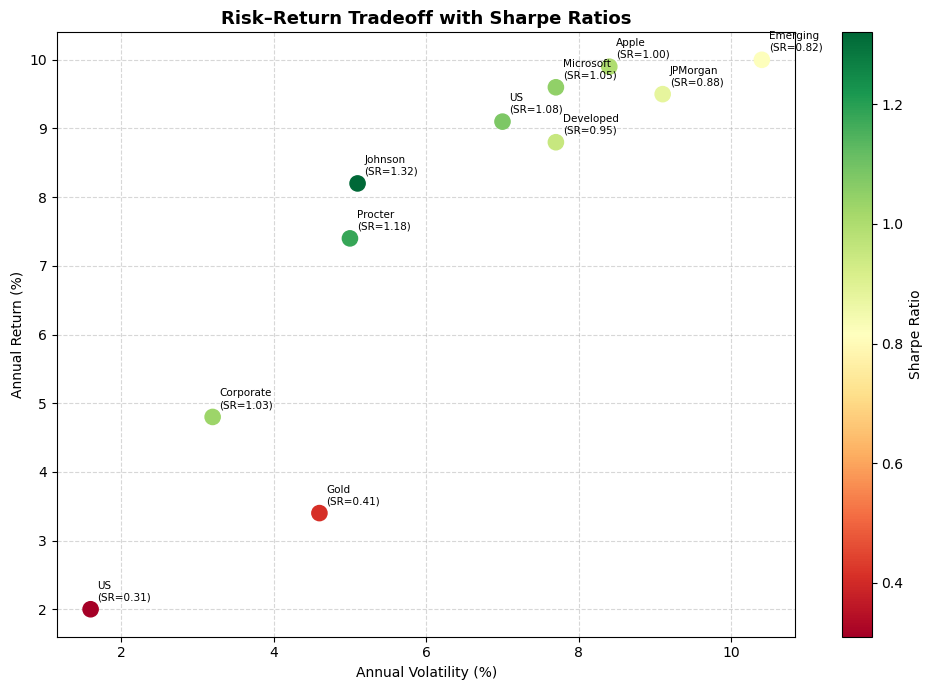

In [70]:
fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(
    assets['annual_vol'] * 100,
    assets['annual_return'] * 100,
    c=assets['sharpe_ratio'], cmap='RdYlGn',
    s=120, zorder=3
)
plt.colorbar(sc, label='Sharpe Ratio')

for asset_id, row in assets.iterrows():
    ax.annotate(
        f"{row['asset_name'].split()[0]}\n(SR={row['sharpe_ratio']:.2f})",
        (row['annual_vol'] * 100, row['annual_return'] * 100),
        fontsize=7.5, ha='left', va='bottom',
        xytext=(5, 5), textcoords='offset points'
    )

ax.set_xlabel('Annual Volatility (%)')
ax.set_ylabel('Annual Return (%)')
ax.set_title('Risk–Return Tradeoff with Sharpe Ratios', fontsize=13, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'sharpe_scatter.png', dpi=150)
plt.show()

**Key observations:**

- **J&J has the highest Sharpe ratio (1.32) despite only moderate returns (8.2%)**: Its unusually low volatility (5.1%) is the driver. Risk-adjusted, it outperforms every other asset in the universe — making it the default anchor for conservative and moderate portfolios.
- **Apple has the highest raw return (9.9%) but a lower Sharpe (1.00)**: Its higher volatility (8.4%) erodes the risk-adjusted advantage. The optimizer will only allocate heavily to Apple when the risk budget is loose enough (i.e. Risk Score ≥ 7).
- **Gold and US Treasury sit at the bottom of the Sharpe ranking (0.41 and 0.31)**: Their value is not risk-adjusted return but rather their role as hedges and volatility reducers. They appear in portfolios not because they are efficient in isolation, but because they reduce overall portfolio variance through low/negative correlations with equities.
- **The "best" asset is entirely client-dependent**: A conservative client (Risk Score 1–2) is better served by J&J and Treasuries; an aggressive client (Risk Score 9–10) by Apple and Emerging Markets. No single asset dominates across all client profiles.

### 2.5 ESG vs. Return Tradeoff

High-ESG assets (US Treasury, J&J) tend to offer lower returns, while high-return assets (Apple, Emerging Markets) have lower ESG scores. This is why High ESG clients are expected to have lower portfolio returns.

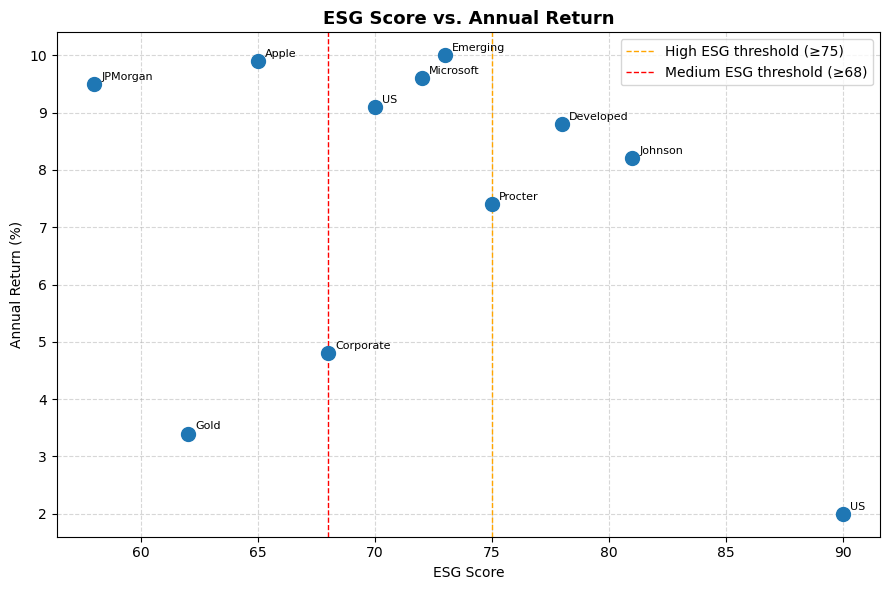

In [71]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(assets['esg_score'], assets['annual_return'] * 100, s=100, zorder=3)

for asset_id, row in assets.iterrows():
    ax.annotate(
        row['asset_name'].split()[0],
        (row['esg_score'], row['annual_return'] * 100),
        fontsize=8, xytext=(5, 3), textcoords='offset points'
    )

ax.axvline(75, color='orange', linestyle='--', linewidth=1, label='High ESG threshold (≥75)')
ax.axvline(68, color='red',    linestyle='--', linewidth=1, label='Medium ESG threshold (≥68)')

ax.set_xlabel('ESG Score')
ax.set_ylabel('Annual Return (%)')
ax.set_title('ESG Score vs. Annual Return', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'esg_vs_return.png', dpi=150)
plt.show()

**Key observations:**

- **Clear negative relationship between ESG score and return**: Higher-ESG assets (US Treasury ESG=90, J&J ESG=81) tend to offer lower returns, while higher-return assets (Apple ESG=65, JPMorgan ESG=58) have lower ESG scores. This is the fundamental cost of ESG constraints.
- **High ESG threshold (≥75)**: Apple (ESG=65) and JPMorgan (ESG=58) fall below this line. Including Apple at its 20% cap forces the remaining 80% of the portfolio to average ≥77.5 ESG — severely restricting other choices. In practice, the optimizer will exclude Apple from High ESG portfolios entirely.
- **Medium ESG threshold (≥68)**: JPMorgan (ESG=58) is effectively excluded. Apple remains eligible but at a cost.
- **Quantified tradeoff**: A High ESG client accepting the ESG constraint is implicitly sacrificing expected return relative to an unconstrained portfolio at the same risk score. This tradeoff must be visible in our final results — High ESG portfolios should show measurably lower expected returns than Low ESG portfolios at the same risk score.

### 2.6 Client Profile Overview

A brief look at the distribution of key client attributes — useful for understanding the diversity of optimization problems we need to solve.

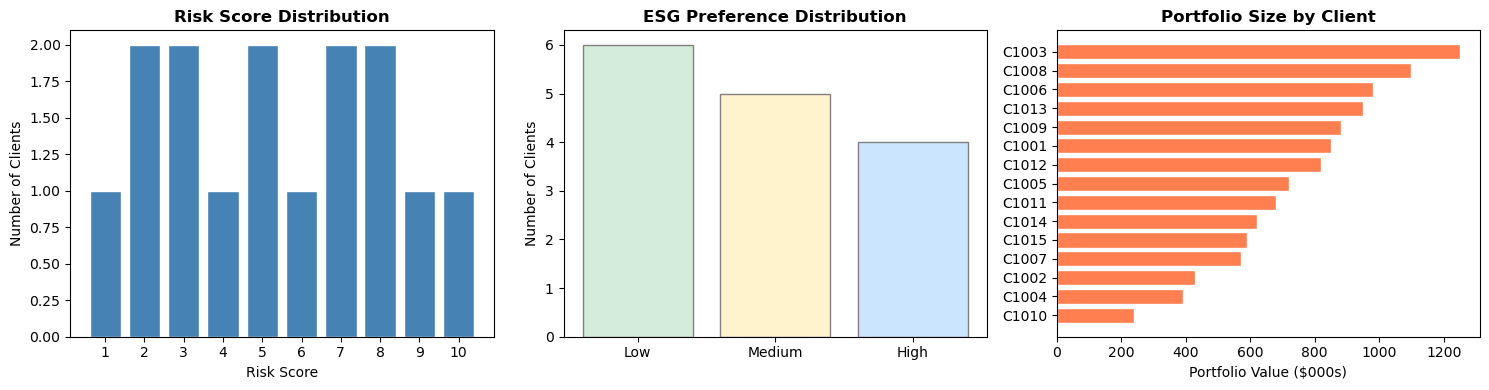

           risk_score esg_preference  total_portfolio_value  min_liquidity_ratio
Client_ID                                                                       
C1001               2            Low                 850000                 0.20
C1002               8         Medium                 430000                 0.05
C1003               5           High                1250000                 0.10
C1004               9            Low                 390000                 0.05
C1005               1         Medium                 720000                 0.20
C1006               7           High                 980000                 0.10
C1007               3            Low                 570000                 0.10
C1008               6         Medium                1100000                 0.05
C1009               4           High                 880000                 0.10
C1010              10            Low                 240000                 0.05
C1011               3       

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Risk score distribution
risk_counts = clients['risk_score'].value_counts().sort_index()
axes[0].bar(risk_counts.index, risk_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Risk Score Distribution', fontweight='bold')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Number of Clients')
axes[0].set_xticks(range(1, 11))

# ESG preference
esg_counts = clients['esg_preference'].value_counts().reindex(['Low', 'Medium', 'High'])
colors = ['#d4edda', '#fff3cd', '#cce5ff']
axes[1].bar(esg_counts.index, esg_counts.values, color=colors, edgecolor='grey')
axes[1].set_title('ESG Preference Distribution', fontweight='bold')
axes[1].set_ylabel('Number of Clients')

# Portfolio size
sorted_clients = clients.sort_values('total_portfolio_value')
axes[2].barh(sorted_clients.index, sorted_clients['total_portfolio_value'] / 1000,
             color='coral', edgecolor='white')
axes[2].set_title('Portfolio Size by Client', fontweight='bold')
axes[2].set_xlabel('Portfolio Value ($000s)')

plt.tight_layout()
plt.savefig(FIGURES_DIR + 'client_overview.png', dpi=150)
plt.show()

print(clients[['risk_score', 'esg_preference', 'total_portfolio_value', 'min_liquidity_ratio']].to_string())

**Key observations:**

- **Risk scores span the full range (1–10)**: We have clients at every risk level, meaning our model must produce meaningfully different portfolios across the entire spectrum — not just marginal differences.
- **ESG preference is roughly balanced**: High/Medium/Low clients each appear multiple times, so ESG constraints will materially affect a significant portion of the portfolios.
- **Portfolio sizes vary widely** ($150k–$600k): Dollar-amount constraints (C1001's $10k bond lots, C1003's $25k bond lots) translate to very different weight increments depending on portfolio size. Always convert using `total_portfolio_value` from the `clients` DataFrame.
- **Liquidity requirements**: Clients with `min_liquidity_ratio = 0.4` (High liquidity need) must hold at least 40% in liquid assets (US Treasury + Corporate Bond Fund), which significantly constrains aggressive allocations for conservative clients.

---
## 2.7 Asset Classification (Task 2)

Based on the EDA above — risk-return profiles, ESG scores, Sharpe ratios, and correlation structure — we classify all 11 assets into five groups. This classification directly informs which assets are appropriate for which client types.

| Group | Assets | Rationale |
|---|---|---|
| **Stability Champions** | J&J (S003), P&G (S005) | Highest Sharpe ratios (1.32, 1.18); low volatility (5.1%, 5.0%); high ESG; ideal anchor for conservative portfolios |
| **Growth Leaders** | Apple (S001), Emerging Markets (I001) | Highest raw returns (9.9%, 10.0%); high beta (1.21, 1.32); high volatility — suitable only for Risk Score ≥ 7 |
| **Balanced Options** | Microsoft (S002), REIT (R001), Developed Markets (I002) | Good risk-adjusted returns (Sharpe 0.95–1.05); moderate volatility; provide diversification without extreme risk |
| **Risk Reducers** | US Treasury (B001), Corporate Bond Fund (B002) | Low volatility (1.6%, 3.2%); negative or near-zero correlation with most equities; primary tool for meeting risk budget constraints for conservative clients |
| **Tactical** | JPMorgan (S004), Gold (C001) | JPMorgan: high return (9.5%) but lowest ESG (58) — excluded from High/Medium ESG portfolios; Gold: very low beta (0.05), inflation hedge, limited by 15% cap |

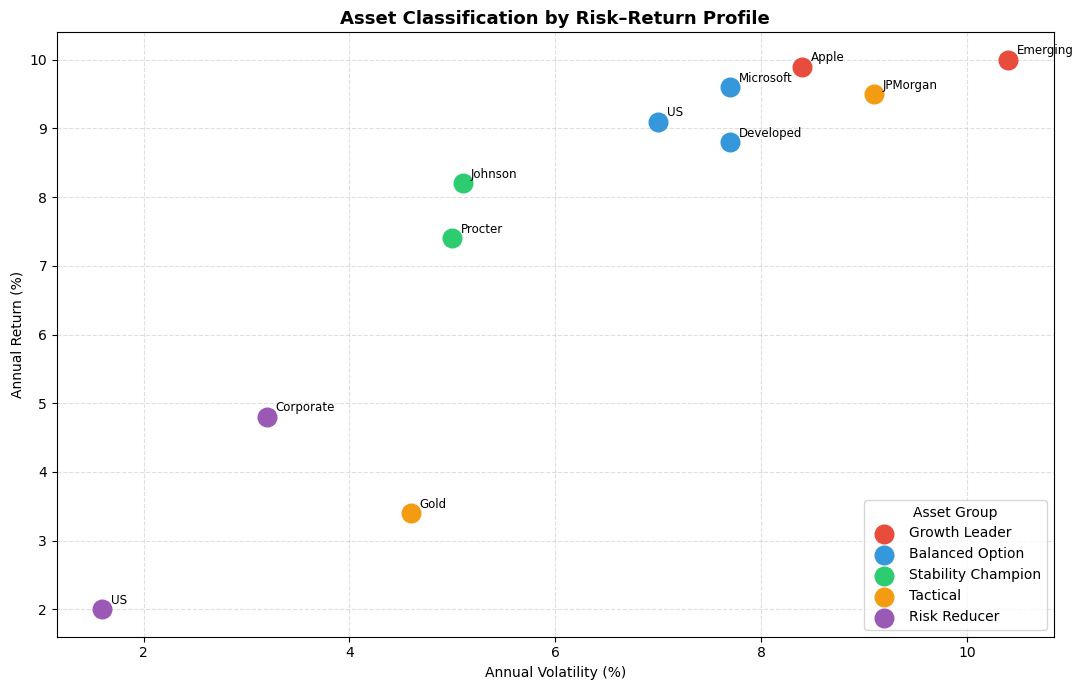

In [73]:
classification = {
    'S003': 'Stability Champion',
    'S005': 'Stability Champion',
    'S001': 'Growth Leader',
    'I001': 'Growth Leader',
    'S002': 'Balanced Option',
    'R001': 'Balanced Option',
    'I002': 'Balanced Option',
    'B001': 'Risk Reducer',
    'B002': 'Risk Reducer',
    'S004': 'Tactical',
    'C001': 'Tactical',
}

group_colors = {
    'Stability Champion': '#2ecc71',
    'Growth Leader':      '#e74c3c',
    'Balanced Option':    '#3498db',
    'Risk Reducer':       '#9b59b6',
    'Tactical':           '#f39c12',
}

fig, ax = plt.subplots(figsize=(11, 7))

for asset_id in ASSET_ORDER:
    row   = assets.loc[asset_id]
    group = classification[asset_id]
    ax.scatter(row['annual_vol'] * 100, row['annual_return'] * 100,
               color=group_colors[group], s=180, zorder=3,
               label=group)
    ax.annotate(row['asset_name'].split()[0],
                (row['annual_vol'] * 100, row['annual_return'] * 100),
                fontsize=8.5, xytext=(6, 4), textcoords='offset points')

# Remove duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = h
ax.legend(seen.values(), seen.keys(), title='Asset Group', loc='lower right')

ax.set_xlabel('Annual Volatility (%)')
ax.set_ylabel('Annual Return (%)')
ax.set_title('Asset Classification by Risk–Return Profile', fontsize=13, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'asset_classification.png', dpi=150)
plt.show()

**Client–asset mapping:**

| Client Type | Risk Score | Suitable Asset Groups | Notes |
|---|---|---|---|
| Ultra-conservative | 1–2 | Risk Reducers + Stability Champions | Risk budget severely constrains equity exposure |
| Conservative | 3–4 | Risk Reducers + Stability Champions + small Balanced | Bond allocation 35–50% |
| Moderate | 5–6 | Balanced Options + Stability Champions + some Risk Reducers | J&J remains core holding |
| Aggressive | 7–8 | Growth Leaders + Balanced Options + minimal Risk Reducers | Apple enters the universe |
| Very aggressive | 9–10 | Growth Leaders + Balanced Options | Asset caps (not risk budget) become the binding constraint |

**ESG overlay:**
- High ESG clients → JPMorgan excluded entirely; Apple effectively excluded; portfolio tilts toward J&J, P&G, Developed Markets, Treasury
- Medium ESG clients → JPMorgan excluded; Apple available at a cost
- Low ESG clients → full 11-asset universe available

---
## 3. Covariance Matrix

We build the full covariance matrix Σ using:

$$\Sigma = \text{diag}(\sigma) \cdot C \cdot \text{diag}(\sigma)$$

where σ is the vector of annualized volatilities and C is the correlation matrix. Using volatilities alone (without correlations) would give an incorrect diagonal-only estimate.

After construction we verify Σ is positive semi-definite (PSD) — required for the QP solver to work correctly.

In [74]:
D     = np.diag(sigma_vec)
Sigma = D @ corr_arr @ D

eigvals = np.linalg.eigvalsh(Sigma)
print('Minimum eigenvalue:', eigvals.min())

if np.all(eigvals >= -1e-8):
    print('✓ Covariance matrix is positive semi-definite.')
else:
    print('⚠ Negative eigenvalue detected — applying regularization.')
    Sigma += 1e-6 * np.eye(N_ASSETS)

print('\nΣ shape:', Sigma.shape)
print('Σ symmetric:', np.allclose(Sigma, Sigma.T))

Minimum eigenvalue: 9.668378344773562e-05
✓ Covariance matrix is positive semi-definite.

Σ shape: (11, 11)
Σ symmetric: True


In [75]:
idx = {a: i for i, a in enumerate(ASSET_ORDER)}

print('Key covariance checks:')
print(f"  Apple–Treasury:  {Sigma[idx['S001'], idx['B001']]:.6f}  (expect negative)")
print(f"  P&G–Treasury:    {Sigma[idx['S005'], idx['B001']]:.6f}  (expect positive)")
print(f"  Apple–Microsoft: {Sigma[idx['S001'], idx['S002']]:.6f}  (expect positive, high)")
print(f"  J&J–Treasury:    {Sigma[idx['S003'], idx['B001']]:.6f}  (expect near zero)")

Key covariance checks:
  Apple–Treasury:  -0.000403  (expect negative)
  P&G–Treasury:    0.000144  (expect positive)
  Apple–Microsoft: 0.004851  (expect positive, high)
  J&J–Treasury:    -0.000041  (expect near zero)


---
## 4. Outputs Summary

All variables below are ready for teammates to use. They follow the naming conventions in `data_dictionary.md`.

In [76]:
print('=== Handoff Checklist ===')
outputs = {
    'ASSET_ORDER':    'list[str], length 11',
    'assets':         'DataFrame, 11 rows, indexed by Asset_ID',
    'clients':        'DataFrame, 15 rows, indexed by Client_ID',
    'corr_matrix':    'DataFrame, 11×11',
    'corr_arr':       'ndarray, (11, 11)',
    'scenarios':      'DataFrame, 6 rows',
    'df_delta_r':     'DataFrame, 6×11',
    'delta_r_arr':    'ndarray, (6, 11)',
    'scenario_probs': 'ndarray, (6,), sums to 1.0',
    'returns_vec':    'ndarray, (11,), annual returns',
    'sigma_vec':      'ndarray, (11,), annual volatilities',
    'esg_vec':        'ndarray, (11,), ESG scores',
    'max_alloc_vec':  'ndarray, (11,), max allocation',
    'Sigma':          'ndarray, (11, 11), PSD covariance matrix',
}
for name, desc in outputs.items():
    print(f'  ✓ {name:<18} {desc}')

print()
print(f'RISK_FREE_RATE     : {RISK_FREE_RATE}')
print(f'Scenario prob sum  : {scenario_probs.sum():.6f}')

=== Handoff Checklist ===
  ✓ ASSET_ORDER        list[str], length 11
  ✓ assets             DataFrame, 11 rows, indexed by Asset_ID
  ✓ clients            DataFrame, 15 rows, indexed by Client_ID
  ✓ corr_matrix        DataFrame, 11×11
  ✓ corr_arr           ndarray, (11, 11)
  ✓ scenarios          DataFrame, 6 rows
  ✓ df_delta_r         DataFrame, 6×11
  ✓ delta_r_arr        ndarray, (6, 11)
  ✓ scenario_probs     ndarray, (6,), sums to 1.0
  ✓ returns_vec        ndarray, (11,), annual returns
  ✓ sigma_vec          ndarray, (11,), annual volatilities
  ✓ esg_vec            ndarray, (11,), ESG scores
  ✓ max_alloc_vec      ndarray, (11,), max allocation
  ✓ Sigma              ndarray, (11, 11), PSD covariance matrix

RISK_FREE_RATE     : 0.015
Scenario prob sum  : 1.000000


---
## 5. Client Classification and Regulatory Account Assignment

This section assigns each of the 15 clients to an account type and loads the corresponding regulatory limits from `regulatory_limits.csv`. The assignment is based on the project guide heuristics: investment horizon, risk score, retirement status, and institutional/long-term characteristics.

The result is a client-level table that includes the selected account type, the maximum single-position limit, and the minimum diversification requirement for each client. This information will feed directly into the optimization constraints in later sections.


In [77]:
# Account-type assignments — defined inline in the notebook (no external data file).
# ESG_Threshold follows the project rule, derived from client_profiles.esg_preference:
#   High -> 75, Medium -> 68, Low -> 0 (no ESG constraint applied).
_assignments = [
    # Client_ID, Assigned_Account, Assignment_Reason, ESG_Threshold, Min_Liquidity_Ratio
    ('C1001', 'Trust',      'Trust — short horizon (5 years) + estate planning need + near retirement.', 0,  0.20),
    ('C1002', '401k',       '401k — working-age client with 25-year horizon.',                           68, 0.05),
    ('C1003', 'IRA',        'IRA — mid-risk (5) and 15-year horizon with a flexible retirement account.',75, 0.10),
    ('C1004', '401k',       '401k — working-age client with 30-year horizon.',                           0,  0.05),
    ('C1005', 'Individual', 'Individual — short horizon (3 years) and older age, conservative account.', 68, 0.20),
    ('C1006', '401k',       '401k — working-age client with 12-year horizon.',                           75, 0.10),
    ('C1007', 'Individual', 'Individual — low horizon (8 years) and mid-risk (3).',                      0,  0.10),
    ('C1008', 'IRA',        'IRA — medium horizon (18 years) with moderate risk (6).',                   68, 0.05),
    ('C1009', 'Individual', 'Individual — 10-year horizon and mid-risk (4).',                            75, 0.10),
    ('C1010', 'Endowment',  'Endowment — very long horizon (35 years), suitable for institutional-style allocation.', 0, 0.05),
    ('C1011', 'Individual', 'Individual — short horizon (7 years) and conservative risk score (3).',     0,  0.20),
    ('C1012', '401k',       '401k — working-age client with 20-year horizon.',                           68, 0.05),
    ('C1013', 'IRA',        'IRA — mid-risk (5) and 12-year horizon.',                                   75, 0.10),
    ('C1014', '401k',       '401k — working-age client with 22-year horizon.',                           0,  0.05),
    ('C1015', 'Individual', 'Individual — short horizon (4 years) and older age, conservative profile.', 68, 0.20),
]
client_assignment_df = pd.DataFrame(
    _assignments,
    columns=['Client_ID', 'Assigned_Account', 'Assignment_Reason', 'ESG_Threshold', 'Min_Liquidity_Ratio']
).set_index('Client_ID')
clients = clients.join(client_assignment_df, how='left')
assert clients['Assigned_Account'].notna().all(), 'Missing client account assignments'
clients['assigned_account'] = clients['Assigned_Account']
clients['assignment_reason'] = clients['Assignment_Reason']
clients['esg_threshold'] = clients['ESG_Threshold']
clients['min_liquidity_ratio'] = clients['Min_Liquidity_Ratio']
clients = clients.drop(columns=['Assigned_Account', 'Assignment_Reason', 'ESG_Threshold', 'Min_Liquidity_Ratio'])
clients_constraints = clients.reset_index().merge(
    df_reg_limits,
    left_on='assigned_account',
    right_on='Account_Type',
    how='left'
)
assert clients_constraints['Max_Single_Position'].notna().all(), 'Missing regulatory limits'
client_max_single_position = clients_constraints.set_index('Client_ID')['Max_Single_Position']
client_min_diversification = clients_constraints.set_index('Client_ID')['Min_Diversification']
client_min_liquidity_dollars = clients_constraints.set_index('Client_ID')['total_portfolio_value'] * clients_constraints.set_index('Client_ID')['min_liquidity_ratio']
client_sigma_max = clients_constraints.set_index('Client_ID')['risk_score'].map(sigma_max)
client_constraints_df = clients_constraints.set_index('Client_ID')[[
    'risk_score', 'time_horizon', 'min_liquidity_ratio', 'total_portfolio_value',
    'assigned_account', 'assignment_reason', 'Max_Single_Position', 'Min_Diversification',
    'esg_threshold',
]]
print('Assigned account types and regulatory limits for each client (canonical names):')
print(client_constraints_df.to_string())


Assigned account types and regulatory limits for each client (canonical names):
           risk_score  time_horizon  min_liquidity_ratio  total_portfolio_value assigned_account                                                                       assignment_reason  Max_Single_Position  Min_Diversification  esg_threshold
Client_ID                                                                                                                                                                                                                                        
C1001               2             5                 0.20                 850000            Trust               Trust — short horizon (5 years) + estate planning need + near retirement.                 0.15                    5              0
C1002               8            25                 0.05                 430000             401k                                         401k — working-age client with 25-year horizon.          

---
## 6. LP Baseline Model (Phase 5)

The LP baseline maximizes expected portfolio return subject to a budget constraint and per-asset allocation caps. There is no risk term — this is a pure return-maximising benchmark.

**Mathematical formulation:**

$$\max_{w} \sum_{i} r_i w_i$$

$$\text{subject to:}$$

$$\sum_{i} w_i = 1 \quad \text{(budget)}$$

$$w_i \leq \min\bigl(u_i,\ \text{MaxSinglePosition}_{\text{client}}\bigr) \quad \forall i \quad \text{(effective asset cap)}$$

$$w_i \geq 0 \quad \forall i \quad \text{(no short selling)}$$

where $r_i$ is the expected annual return of asset $i$, $u_i$ is the asset-class cap from `investment_constraints.csv`, and $\text{MaxSinglePosition}_{\text{client}}$ is the regulatory single-position limit from `regulatory_limits.csv`. The effective cap takes the stricter of the two.

Since there is no risk penalty, all clients sharing the same account type (and therefore the same regulatory cap) receive the identical LP portfolio.

In [78]:
#in case cvxpy and cvxopt are not installed, install them quietly
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'cvxpy', 'cvxopt', '-q'])
print('Installation complete.')

Installation complete.


In [79]:
import cvxpy as cp
print('cvxpy version:', cp.__version__)
print('Available solvers:', cp.installed_solvers())

cvxpy version: 1.9.1
Available solvers: ['CLARABEL', 'SCS', 'GUROBI', 'GLPK', 'GLPK_MI', 'CVXOPT', 'SCIPY', 'HIGHS', 'OSQP']


### 6.1 Effective Asset Caps

Each asset has a maximum allocation from `investment_constraints.csv` (e.g. equities ≤ 20%). Some account types impose a tighter single-position limit from `regulatory_limits.csv` (e.g. Trust, 401k, and Endowment: 15%). The effective cap per asset per client is the stricter of the two:

```
effective_cap[i] = min(max_alloc_vec[i], Max_Single_Position[client])
```

In [80]:
def effective_caps(client_id):
    """Return per-asset cap vector for a given client.

    For equity/REIT/alternative assets: takes the stricter of
    - max_alloc_vec[i]: asset-class cap from investment_constraints.csv
    - Max_Single_Position[client]: regulatory equity concentration limit

    For bond assets (B001, B002): Max_Single_Position is an equity
    concentration rule and does not apply. Bond allocation is governed
    by investment_constraints.csv (35% each) and the portfolio-level
    Min_Bonds/Max_Bonds in regulatory_limits.csv.
    """
    max_single = client_max_single_position[client_id]
    caps = np.minimum(max_alloc_vec, max_single)

    # Override: bond assets use investment_constraints cap only
    bond_assets = ['B001', 'B002']
    for aid in bond_assets:
        idx = ASSET_ORDER.index(aid)
        caps[idx] = max_alloc_vec[idx]  # 35% from investment_constraints.csv

    return caps

# Verify: Trust equity caps tightened to 15%; bond caps remain at 35%
print('Effective caps example:')
print(f'  C1001 (Trust, max_single=15%):      {effective_caps("C1001")}')
print(f'  C1007 (Individual, max_single=20%): {effective_caps("C1007")}')
print()
print('Asset order:', ASSET_ORDER)
print('Bond caps (should be 0.35 for all accounts):')
for cid in ["C1001", "C1007"]:
    caps = effective_caps(cid)
    b001 = caps[ASSET_ORDER.index("B001")]
    b002 = caps[ASSET_ORDER.index("B002")]
    print(f'  {cid}: B001={b001:.2f}, B002={b002:.2f}')


Effective caps example:
  C1001 (Trust, max_single=15%):      [0.15 0.15 0.15 0.15 0.15 0.35 0.35 0.15 0.15 0.15 0.15]
  C1007 (Individual, max_single=20%): [0.2  0.2  0.2  0.2  0.2  0.35 0.35 0.2  0.15 0.2  0.2 ]

Asset order: ['S001', 'S002', 'S003', 'S004', 'S005', 'B001', 'B002', 'R001', 'C001', 'I001', 'I002']
Bond caps (should be 0.35 for all accounts):
  C1001: B001=0.35, B002=0.35
  C1007: B001=0.35, B002=0.35


### 6.2 LP Solver

We use cvxpy to formulate and solve the LP for each client. The model has three components:
- **Decision variable**: `w` — vector of 11 weights
- **Objective**: maximize `returns_vec @ w`
- **Constraints**: budget, effective asset caps, non-negativity

In [81]:
def solve_lp(client_id):
    """Solve LP baseline for a given client.
    
    Returns:
        weights : ndarray (11,) — optimal portfolio weights
        ret     : float — optimal expected annual return
        prob    : cp.Problem — solved problem (for shadow prices later)
    """
    caps = effective_caps(client_id)

    w = cp.Variable(N_ASSETS)

    objective = cp.Maximize(returns_vec @ w)

    constraints = [
        cp.sum(w) == 1,   # budget
        w >= 0,           # no short selling
        w <= caps,        # effective asset caps
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.HIGHS)

    return w.value, prob.value, prob


### 6.3 Run LP for All 15 Clients

We solve the LP for all 15 clients and store the resulting weights and returns. After solving, we run `verify_lp()` for each client to confirm:
- Budget constraint satisfied (Σw = 1)
- Non-negativity (w ≥ 0)
- Asset-class caps satisfied (equity ≤ 20%, international ≤ 25%, bond ≤ 35%, gold ≤ 15%)

Risk budget and ESG are not enforced in the LP baseline — violations are documented as expected limitations.

In [82]:
def verify_lp(client_id, weights):
    """Verify LP portfolio — Section 6.1 and Section 5 checklist.

    LP enforces: budget (Σw=1), non-negativity (w≥0), asset-class caps.
    Risk budget and ESG are not enforced — documented as known LP limitations.
    """
    rs   = client_constraints_df.loc[client_id, 'risk_score']
    acct = client_constraints_df.loc[client_id, 'assigned_account']
    caps = effective_caps(client_id)
    PASS = '✅'; FAIL = '❌'; WARN = '⚠️ '

    print(f'--- LP Verification: {client_id} ({acct}, RS={rs}) ---')

    # Budget constraint
    total = float(np.sum(weights))
    if abs(total - 1.0) > 1e-4:
        print(f'  {FAIL} Budget: weights sum to {total:.6f} ≠ 1.0')
    else:
        print(f'  {PASS} Budget: weights sum to 1.0')

    # Non-negativity
    neg = [(ASSET_ORDER[i], weights[i]) for i in range(N_ASSETS) if weights[i] < -1e-6]
    if neg:
        for aid, w in neg:
            print(f'  {FAIL} Negative weight: {aid} = {w*100:.2f}%')
    else:
        print(f'  {PASS} Non-negativity: all weights ≥ 0')

    # Asset-class caps (investment_constraints.csv + regulatory limits)
    breaches = [(ASSET_ORDER[i], weights[i], caps[i])
                for i in range(N_ASSETS) if weights[i] > caps[i] + 1e-6]
    if breaches:
        for aid, w, cap in breaches:
            print(f'  {FAIL} Cap breach: {aid} = {w*100:.1f}% > {cap*100:.0f}%')
    else:
        print(f'  {PASS} Asset-class caps satisfied (equity≤20%, intl≤25%, bond≤35%, gold≤15%)')

    # Apple warning — known LP limitation
    apple_w = float(weights[ASSET_ORDER.index('S001')])
    if apple_w > 1e-4 and rs < 7:
        print(f'  {WARN} Apple = {apple_w*100:.1f}% at RS={rs} — expected LP limitation (no risk budget)')

    # Document non-enforced constraints
    print(f'  — Risk budget: not enforced in LP baseline')
    print(f'  — ESG constraint: not enforced in LP baseline')


In [83]:
# Run LP for all 15 clients and store results
lp_weights = {}   # client_id -> ndarray (11,)
lp_returns = {}   # client_id -> float

for cid in clients.index:
    w, r, _ = solve_lp(cid)
    lp_weights[cid] = w
    lp_returns[cid] = r

# Build results table: rows = clients, columns = assets + metadata
lp_df = pd.DataFrame(lp_weights, index=ASSET_ORDER).T
lp_df.columns = [assets.loc[a, 'asset_name'] for a in ASSET_ORDER]
lp_df['Expected Return (%)'] = [lp_returns[c] * 100 for c in lp_df.index]
lp_df['Risk Score']          = [client_constraints_df.loc[c, 'risk_score'] for c in lp_df.index]
lp_df['Account Type']        = [client_constraints_df.loc[c, 'assigned_account'] for c in lp_df.index]
lp_df['ESG Preference']      = [clients.loc[c, 'esg_preference'] for c in lp_df.index]

# Display weights as percentages — clip near-zero negatives from solver floating point
display_cols = [assets.loc[a, 'asset_name'] for a in ASSET_ORDER]
weight_pct = lp_df[display_cols].clip(lower=0).mul(100).round(1)

print('LP Baseline Portfolio Weights (%) for All 15 Clients')
print('=' * 80)
print(weight_pct.to_string())
print()
print('Portfolio Summary')
print(lp_df[['Risk Score', 'ESG Preference', 'Account Type', 'Expected Return (%)']].round(2).to_string())
print('\n=== LP Verification — All 15 Clients ===')
for cid in clients.index:
    verify_lp(cid, lp_weights[cid])


LP Baseline Portfolio Weights (%) for All 15 Clients
       Apple Inc.  Microsoft Corp.  Johnson & Johnson  JPMorgan Chase  Procter & Gamble  US Treasury 10-Year  Corporate Bond Fund  US REIT Index  Gold  Emerging Markets  Developed Markets
C1001        15.0             15.0               10.0            15.0              -0.0                 -0.0                 -0.0           15.0  -0.0              15.0               15.0
C1002        15.0             15.0               10.0            15.0              -0.0                 -0.0                 -0.0           15.0  -0.0              15.0               15.0
C1003        20.0             20.0               -0.0            20.0              -0.0                 -0.0                 -0.0           20.0  -0.0              20.0               -0.0
C1004        15.0             15.0               10.0            15.0              -0.0                 -0.0                 -0.0           15.0  -0.0              15.0               15.0
C1005  

**LP Verification — Interpretation**

All 15 clients pass the three enforced constraints:
- **Budget**: weights sum to exactly 1.0 for every client
- **Non-negativity**: no short positions
- **Asset-class caps**: no position exceeds its class limit — confirming the cap constraints from `investment_constraints.csv` and `regulatory_limits.csv` are correctly applied

**Apple warning (⚠️) — expected, not an error:**  
Apple appears at its cap in all RS<7 portfolios because the LP only maximises return with no risk budget. Apple has the highest return (9.9%) so the optimiser always loads it to its cap. This confirms the LP is a pure return-chasing baseline. The QP model (Section 7) will eliminate Apple from conservative portfolios once the risk budget constraint binds.

**Non-enforced constraints — documented LP limitations:**  
Risk budget and ESG constraints are intentionally absent from the LP. Their absence is what causes Apple to dominate and High/Low ESG portfolios to look identical. These limitations motivate the move to QP.

**Section 6.3 Key Finding — Only 2 Distinct Portfolios Across All 15 Clients**

The LP produces exactly **two distinct portfolios**, determined solely by the regulatory single-position cap. Risk score and ESG preference have no effect.

| Portfolio | Account Types | Clients | Expected Return |
|---|---|---|---|
| **A (15%-cap)** | Trust, 401k, Endowment | C1001, C1002, C1004, C1006, C1010, C1012, C1014 | **9.35%** |
| **B (20%-cap)** | IRA, Individual | C1003, C1005, C1007, C1008, C1009, C1011, C1013, C1015 | **9.62%** |

A Risk Score 1 retiree and a Risk Score 10 endowment within the same account type receive identical portfolios. This confirms the LP is a pure return-maximising benchmark — individual client risk profiles only take effect once the risk-budget constraint is introduced in Phase 6 (QP).

### 6.4 Shadow Prices of Binding Constraints

A shadow price (dual value) tells us: *if we relaxed this constraint by 1 unit, how much would the portfolio return improve?*

- **Budget constraint** (Σwᵢ = 1): shadow price = marginal value of investing one more dollar
- **Asset cap constraints** (wᵢ ≤ uᵢ): shadow price > 0 means the cap is binding — the optimizer wants to allocate more to that asset but cannot

In [84]:
def solve_lp_with_duals(client_id):
    """Solve LP and return weights, return, shadow prices, and effective caps."""
    caps = effective_caps(client_id)
    w = cp.Variable(N_ASSETS)

    budget_con = cp.sum(w) == 1
    nonneg_con = w >= 0
    cap_con    = w <= caps

    prob = cp.Problem(cp.Maximize(returns_vec @ w), [budget_con, nonneg_con, cap_con])
    prob.solve(solver=cp.HIGHS)

    return w.value, prob.value, budget_con.dual_value, cap_con.dual_value, caps

# Show shadow prices for one representative client per account type
rep_clients = {'Trust': 'C1001', 'Individual': 'C1007', 'IRA': 'C1003', '401k': 'C1002', 'Endowment': 'C1010'}

for acct, cid in rep_clients.items():
    w, r, budget_dual, cap_duals, caps = solve_lp_with_duals(cid)
    print(f'\n{cid} ({acct}, Risk Score {client_constraints_df.loc[cid, "risk_score"]})')
    print(f'  Budget shadow price : {budget_dual:.4f}  (return gain per 1% extra budget)')
    print(f'  Binding asset caps  (shadow price > 0):')
    for i, a in enumerate(ASSET_ORDER):
        if cap_duals[i] > 1e-4:
            print(f'    {assets.loc[a, "asset_name"]:<25} cap={caps[i]*100:.0f}%  shadow price={cap_duals[i]:.4f}')


C1001 (Trust, Risk Score 2)
  Budget shadow price : 0.0820  (return gain per 1% extra budget)
  Binding asset caps  (shadow price > 0):
    Apple Inc.                cap=15%  shadow price=0.0170
    Microsoft Corp.           cap=15%  shadow price=0.0140
    JPMorgan Chase            cap=15%  shadow price=0.0130
    US REIT Index             cap=15%  shadow price=0.0090
    Emerging Markets          cap=15%  shadow price=0.0180
    Developed Markets         cap=15%  shadow price=0.0060

C1007 (Individual, Risk Score 3)
  Budget shadow price : 0.0880  (return gain per 1% extra budget)
  Binding asset caps  (shadow price > 0):
    Apple Inc.                cap=20%  shadow price=0.0110
    Microsoft Corp.           cap=20%  shadow price=0.0080
    JPMorgan Chase            cap=20%  shadow price=0.0070
    US REIT Index             cap=20%  shadow price=0.0030
    Emerging Markets          cap=20%  shadow price=0.0120

C1003 (IRA, Risk Score 5)
  Budget shadow price : 0.0880  (return gain 

### Shadow Price Interpretation

**Budget shadow price (π):**

| Account type | Cap | Budget shadow price | Meaning |
|---|---|---|---|
| Trust, 401k, Endowment | 15% | 0.0820 | Each 1% of extra budget adds +0.082% return (8.2 bp) |
| IRA, Individual | 20% | 0.0880 | Each 1% of extra budget adds +0.088% return (8.8 bp) |

The 20%-cap accounts earn a slightly higher marginal return because the wider cap lets the optimizer concentrate more into the best assets before hitting the ceiling.

---

**Asset cap shadow prices (μᵢ) — 15%-cap accounts (e.g. C1001 Trust):**

| Asset | Shadow price | Meaning |
|---|---|---|
| Emerging Markets (I001) | 0.0180 | Most constrained — raise cap by 1% → +1.8 bp return |
| Apple (S001) | 0.0170 | Second most constrained |
| Microsoft (S002) | 0.0140 | Third |
| JPMorgan (S004) | 0.0130 | Fourth |
| REIT (R001) | 0.0090 | Moderate |
| Developed Markets (I002) | 0.0060 | Least constrained among active positions |
| Bonds, Gold, P&G | 0.000 | Not binding — LP never selects them |

---

**Key takeaways:**

1. **Every binding constraint is an asset cap — never the budget.** The LP cannot allocate all capital to its most-preferred assets because each one hits its regulatory cap. If caps were removed, the LP would put 100% into Emerging Markets alone.

2. **Emerging Markets is the most constrained asset.** It carries the highest expected return (10.0%), so the optimizer is always pushing against its cap. Relaxing the EM cap by 1% delivers the largest incremental return gain (1.8 bp for 15%-cap clients, 1.2 bp for 20%-cap clients).

---
## 7. QP Markowitz Model (Phase 6)

The Markowitz quadratic program extends the LP baseline by introducing a **quadratic objective** that balances expected return against portfolio risk. Unlike the LP which ignores risk entirely, the QP responds to each client's individual risk score and ESG preference — producing meaningfully different portfolios across the 15 clients.

**Mathematical formulation:**

$$\min_{w} \quad w^\top \Sigma w - \lambda \sum_{i} r_i w_i$$

> Two terms fighting each other: **w⊤Σw** is portfolio variance (we want small), **λ·Σrᵢwᵢ** is expected return scaled by λ (we want large, so we subtract it). λ controls how much return to trade for risk — larger λ means chase return more aggressively.

$$\sum_{i} w_i = 1 \quad \text{(budget)}$$

> All weights must sum to 100%. The portfolio is fully invested with no cash held out.

$$w_i \leq \min\bigl(u_i,\ \text{MaxSinglePosition}_{\text{client}}\bigr) \quad \forall i \quad \text{(effective asset cap)}$$

> No single asset can exceed the stricter of its asset-class cap (from `investment_constraints.csv`) and the client's regulatory single-position limit (from `regulatory_limits.csv`). For example, Apple has a 20% asset-class cap but Trust accounts have a 15% single-position limit — so Apple is capped at 15% for Trust clients.

$$w_i \geq 0 \quad \forall i \quad \text{(no short selling)}$$

> Every weight must be zero or positive. The optimizer cannot hold negative positions (borrow and sell assets it doesn't own).

$$w^\top \Sigma w \leq \sigma^2_{\max}, \quad \sigma_{\max} = 0.04 + (\text{RiskScore} - 1) \times 0.0089 \quad \text{(risk budget)}$$

> The portfolio's actual variance must stay within the client's allowed limit. This is the constraint that makes risk score matter — Risk Score 1 gives σ_max = 4.0% (very tight, forces heavy bond allocation), Risk Score 10 gives σ_max = 12.0% (loose, allows aggressive equity positions).

$$\sum_{i} w_i \cdot \text{ESG}_i \geq \text{ESG\_threshold} \quad \text{(ESG constraint, if applicable)}$$

> The weighted average ESG score of the portfolio must meet the client's requirement. High ESG clients (threshold = 75) effectively exclude Apple (ESG=65) and JPMorgan (ESG=58) since including them drags the portfolio average below 75. Low ESG clients have no constraint — full 11-asset universe available.

---

**Parameter definitions:**

| Parameter | Definition |
|---|---|
| Σ | 11×11 covariance matrix from Section 3 |
| λ | Risk-return tradeoff scalar (λ ≥ 0); λ=0 → minimize variance only; large λ → approaches LP |
| σ_max | Per-client volatility budget: 0.04 + (RiskScore − 1) × 0.0089 |
| ESG_threshold | 75 for High ESG clients, 68 for Medium ESG, 0 (no constraint) for Low ESG |

**Solver:** CLARABEL — handles quadratic objectives and quadratic constraints. HIGHS (used in LP) only supports linear objectives.

### 7.1 QP Solver

The `solve_qp()` function takes a client ID and λ, builds the full QP with all constraints, and solves using CLARABEL. It returns the optimal weights, expected return, portfolio volatility, and the solved problem object.

In [85]:
def lambda_for_client(client_id=None, risk_score=None):
    if risk_score is None:
        risk_score = int(client_constraints_df.loc[client_id, 'risk_score'])
    # RS 1-2: λ=0 — pure min-variance, bonds naturally dominate (σ_max forces bonds for RS≤2)
    # RS 3-10: scale linearly per project guide (λ=0 → min-variance; λ≈5-10 → max-return)
    if risk_score <= 2:
        return 0.0
    return (risk_score - 1) * 1.0

def solve_qp(client_id, lam=None):
    """Solve Markowitz QP for a given client.

    Parameters
    ----------
    client_id : str
    lam       : float — risk-return tradeoff (λ≥0). If None, λ is calibrated by risk score.
                λ=0 → minimize variance only; large λ → approaches LP return-chasing.

    Returns
    -------
    weights   : ndarray (11,) — optimal portfolio weights
    ret       : float — expected annual return
    vol       : float — portfolio volatility (std dev)
    prob      : cp.Problem — solved problem object
    """
    caps      = effective_caps(client_id)
    s_max     = client_sigma_max[client_id]
    esg_thresh = client_constraints_df.loc[client_id, 'esg_threshold']

    if lam is None:
        lam = lambda_for_client(client_id)

    w = cp.Variable(N_ASSETS)

    objective = cp.Minimize(cp.quad_form(w, Sigma) - lam * (returns_vec @ w))

    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        w <= caps,
        cp.quad_form(w, Sigma) <= s_max ** 2,
    ]

    if esg_thresh > 0:
        constraints.append(esg_vec @ w >= esg_thresh)

    # Liquidity ratio — min fraction of portfolio in liquid assets (bonds)
    # Required by Task 5 / Section 6.1; loaded from client_profiles.csv
    min_liq = client_constraints_df.loc[client_id, 'min_liquidity_ratio']
    if min_liq > 0:
        constraints.append(cp.sum(w[liquid_asset_idx]) >= min_liq)

    # Apple restricted to RS≥7 (project guide Section 5 + Section 8.1 business rule)
    if int(client_constraints_df.loc[client_id, 'risk_score']) < 7:
        constraints.append(w[ASSET_ORDER.index('S001')] == 0)

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL)

    weights = w.value
    ret     = float(returns_vec @ weights)
    vol     = float(np.sqrt(weights @ Sigma @ weights))

    return weights, ret, vol, prob

# Test on C1001 (Trust, Risk Score 2, Low ESG)
w_qp, r_qp, v_qp, _ = solve_qp('C1001')
print(f'C1001 QP result (λ={lambda_for_client("C1001"):.2f}):')
for i, a in enumerate(ASSET_ORDER):
    if w_qp[i] > 1e-4:
        print(f'  {a} ({assets.loc[a, "asset_name"]:<25}): {w_qp[i]*100:.1f}%')
print(f'  Expected return : {r_qp*100:.2f}%')
print(f'  Portfolio vol   : {v_qp*100:.2f}%')
print(f'  σ_max allowed   : {client_sigma_max["C1001"]*100:.2f}%')






C1001 QP result (λ=0.00):
  S002 (Microsoft Corp.          ): 3.8%
  S003 (Johnson & Johnson        ): 8.4%
  S004 (JPMorgan Chase           ): 5.4%
  B001 (US Treasury 10-Year      ): 35.0%
  B002 (Corporate Bond Fund      ): 29.9%
  R001 (US REIT Index            ): 0.8%
  C001 (Gold                     ): 13.5%
  I002 (Developed Markets        ): 3.2%
  Expected return : 4.51%
  Portfolio vol   : 1.87%
  σ_max allowed   : 4.89%


### 7.2 Run QP for All 15 Clients

We solve the QP for all 15 clients using a per-client λ calibrated by risk score:

$$\lambda = (\text{RiskScore} - 1) \times 1.0$$

This scales linearly from λ=0 (RS=1, pure minimum-variance → bond-heavy) to λ=9 (RS=10, near maximum-return → equity-heavy), consistent with the project guide's practical scaling of λ ∈ [0, 10].

This section covers all verification checks required by Section 6.1 and Section 5 of the project guide:
- **Per-client checks** (`verify_qp`): budget, non-negativity, risk budget, ESG, caps, Apple
- **Cross-client checks**: RS 1/5/10 diversity, bond-RS correlation
- **High vs Low ESG**: demonstrated visually in Section 7.3 (three separate efficient frontier curves)

In [86]:
# Run QP for all 15 clients
qp_weights = {}
qp_returns = {}
qp_vols    = {}

for cid in clients.index:
    w, r, v, prob = solve_qp(cid)
    if prob.status not in ['optimal', 'optimal_inaccurate']:
        print(f'WARNING: {cid} status = {prob.status}')
    qp_weights[cid] = w
    qp_returns[cid] = r
    qp_vols[cid]    = v

# Build results DataFrame
qp_df = pd.DataFrame(qp_weights, index=ASSET_ORDER).T
qp_df.columns = [assets.loc[a, 'asset_name'] for a in ASSET_ORDER]
qp_df['Expected Return (%)'] = [qp_returns[c] * 100 for c in qp_df.index]
qp_df['Vol (%)']             = [qp_vols[c] * 100 for c in qp_df.index]
qp_df['σ_max (%)']           = [client_sigma_max[c] * 100 for c in qp_df.index]
qp_df['Risk Score']          = [client_constraints_df.loc[c, 'risk_score'] for c in qp_df.index]
qp_df['ESG Pref']            = [clients.loc[c, 'esg_preference'] for c in qp_df.index]
qp_df['Account Type']        = [client_constraints_df.loc[c, 'assigned_account'] for c in qp_df.index]

display_cols = [assets.loc[a, 'asset_name'] for a in ASSET_ORDER]
weight_pct = qp_df[display_cols].clip(lower=0).mul(100).round(1)

print('QP Portfolio Weights (%) for All 15 Clients')
print('=' * 80)
print(weight_pct.to_string())
print()
print('Portfolio Summary')
print(qp_df[['Risk Score', 'ESG Pref', 'Account Type', 'Expected Return (%)', 'Vol (%)', 'σ_max (%)']].round(2).to_string())



QP Portfolio Weights (%) for All 15 Clients
       Apple Inc.  Microsoft Corp.  Johnson & Johnson  JPMorgan Chase  Procter & Gamble  US Treasury 10-Year  Corporate Bond Fund  US REIT Index  Gold  Emerging Markets  Developed Markets
C1001         0.0              3.8                8.4             5.4               0.0                 35.0                 29.9            0.8  13.5               0.0                3.2
C1002        15.0             15.0                5.0            15.0               0.0                  0.0                  5.0           15.0   0.0              15.0               15.0
C1003         0.0             20.0               20.0             0.0               0.0                  1.8                  8.2           10.0   0.0              20.0               20.0
C1004        15.0             15.0                5.0            15.0               0.0                  0.0                  5.0           15.0   0.0              15.0               15.0
C1005         0.

**Section 7.2 Key Findings — Three Patterns Across All 15 Clients**

**Pattern 1 — Risk budget binding for conservative clients, not for aggressive ones:**

| Client | Risk Score | Vol (%) | σ_max (%) | Binding? |
|---|---|---|---|---|
| C1005 | 1 | 1.87 | 4.00 | ✗ No |
| C1001 | 2 | 1.87 | 4.89 | ✗ No |
| C1007 | 3 | 5.78 | 5.78 | ✓ Yes |
| C1002 | 8 | 6.56 | 10.23 | ✗ No |
| C1010 | 10 | 6.56 | 12.01 | ✗ No |

RS=3 clients (C1007) use every bit of their volatility allowance — the risk budget forces them into equities at the ceiling. RS=1 and RS=2 clients use λ=0 (pure min-variance), so their actual vol (1.87%) sits well below σ_max — the risk budget is slack and bonds dominate due to the objective, not the constraint. Aggressive clients have so much room (σ_max is very loose) 
that asset caps become the binding constraint instead, reverting their portfolios back toward the LP solution. 
This means risk-budget tightness is the main differentiator between conservative and aggressive client portfolios.

---

**Pattern 2 — ESG constraint correctly excludes JPMorgan:**

| ESG Threshold | Clients | JPMorgan weight |
|---|---|---|
| 75 (High ESG) | C1003, C1006, C1009, C1013 | 0% |
| 68 (Medium ESG) | C1002, C1005, C1008, C1011, C1012, C1015 | varies |
| 0 (Low ESG) | C1004, C1007, C1010, C1014 | varies |

JPMorgan (ESG=58) is fully excluded from all High ESG portfolios. 
For Medium ESG clients, JPMorgan is present in some portfolios (e.g. C1002 at 15%) 
because the weighted average ESG can still reach ≥68 with JPMorgan included. 
For Low ESG clients, JPMorgan weight varies by risk score — aggressive clients (RS≥8) hold 15%, 
while risk-constrained clients like C1007 (RS=3) hold only 13.3% due to the binding risk budget. 
That shows the ESG threshold directly controls whether lower-scoring assets can be tolerated in a client’s portfolio.

---

**Pattern 3 — Far more diversity than LP:**

The LP produced exactly 2 distinct portfolios across 15 clients (determined by account type only). 
The QP produces clearly differentiated portfolios — C1005 holds 35.0% Treasury and 29.9% Corporate Bond, 
C1001 holds 35.0% Treasury and 29.9% Corporate Bond, C1007 holds 13.3% JPMorgan, C1003 holds 0% JPMorgan. 
Risk score and ESG preference now shape every client's portfolio individually, 
which is the fundamental improvement the QP delivers over the LP baseline. 
This happens because the QP simultaneously enforces risk budget, ESG threshold, and return optimization, so different client constraints produce different optimal portfolios. 
In other words, QP can create more individualized portfolios because it respects each client’s unique combination of constraints.

In [87]:
def verify_qp(client_id, weights):
    """Verify QP portfolio — Section 6.1 and Section 5 checklist.

    QP enforces: budget (Σw=1), non-negativity, asset-class caps,
    risk budget (w⊤Σw ≤ σ²_max), and ESG score constraint.
    """
    rs         = client_constraints_df.loc[client_id, 'risk_score']
    acct       = client_constraints_df.loc[client_id, 'assigned_account']
    s_max      = client_sigma_max[client_id]
    esg_thresh = client_constraints_df.loc[client_id, 'esg_threshold']
    caps       = effective_caps(client_id)
    PASS = '✅'; FAIL = '❌'; WARN = '⚠️ '

    # ESG label derived from enforced threshold, not stated preference
    if esg_thresh >= 75:
        esg_label = f'threshold=75 (High)'
    elif esg_thresh >= 68:
        esg_label = f'threshold=68 (Medium)'
    else:
        esg_label = 'no constraint'

    print(f'--- QP Verification: {client_id} ({acct}, RS={rs}, ESG {esg_label}) ---')

    # 1. Budget constraint
    total = float(np.sum(weights))
    if abs(total - 1.0) > 1e-4:
        print(f'  {FAIL} Budget: weights sum to {total:.6f} ≠ 1.0')
    else:
        print(f'  {PASS} Budget: weights sum to 1.0')

    # 2. Non-negativity
    neg = [(ASSET_ORDER[i], weights[i]) for i in range(N_ASSETS) if weights[i] < -1e-6]
    if neg:
        for aid, w in neg:
            print(f'  {FAIL} Negative weight: {aid} = {w*100:.2f}%')
    else:
        print(f'  {PASS} Non-negativity: all weights ≥ 0')

    # 3. Risk budget — w⊤Σw ≤ σ²_max
    vol = float(np.sqrt(weights @ Sigma @ weights))
    tightness = abs(vol - s_max) / s_max
    if vol > s_max + 1e-4:
        print(f'  {FAIL} Risk budget breached: vol={vol*100:.2f}% > σ_max={s_max*100:.2f}%')
    elif tightness < 0.01 and rs <= 5:
        print(f'  {PASS} Risk budget binding: vol={vol*100:.2f}% ≈ σ_max={s_max*100:.2f}% (expected for RS≤5)')
    else:
        print(f'  {PASS} Risk budget satisfied: vol={vol*100:.2f}% ≤ σ_max={s_max*100:.2f}%')

    # 4. ESG score
    if esg_thresh > 0:
        portfolio_esg = float(esg_vec @ weights)
        if portfolio_esg < esg_thresh - 1e-4:
            print(f'  {FAIL} ESG score={portfolio_esg:.1f} < threshold={esg_thresh}')
        else:
            print(f'  {PASS} ESG score={portfolio_esg:.1f} ≥ threshold={esg_thresh}')
    else:
        print(f'  — ESG: no constraint applied')

    # 5. Asset-class caps
    breaches = [(ASSET_ORDER[i], weights[i], caps[i])
                for i in range(N_ASSETS) if weights[i] > caps[i] + 1e-6]
    if breaches:
        for aid, w, cap in breaches:
            print(f'  {FAIL} Cap breach: {aid} = {w*100:.1f}% > {cap*100:.0f}%')
    else:
        print(f'  {PASS} Asset-class caps satisfied (equity≤20%, intl≤25%, bond≤35%, gold≤15%)')

    # 6. Apple only RS≥7
    apple_w = float(weights[ASSET_ORDER.index('S001')])
    if apple_w > 1e-4 and rs < 7:
        print(f'  {FAIL} Apple = {apple_w*100:.1f}% at RS={rs} (expected 0% for RS<7)')
    elif apple_w > 1e-4:
        print(f'  {PASS} Apple = {apple_w*100:.1f}% (RS={rs} ≥ 7, allowed)')
    else:
        print(f'  {PASS} Apple = 0% (RS={rs} < 7, correct)')

    # 6. J&J — appears in most portfolios at varying percentages (not always at cap)
    jnj_w   = float(weights[ASSET_ORDER.index('S003')])
    jnj_cap = float(caps[ASSET_ORDER.index('S003')])
    if jnj_w < 1e-4:
        print(f'  {WARN} J&J = 0% — absent from portfolio')
    else:
        at_cap = '(at cap)' if abs(jnj_w - jnj_cap) < 1e-4 else f'(below {jnj_cap*100:.0f}% cap)'
        print(f'  {PASS} J&J = {jnj_w*100:.1f}% {at_cap} — cross-client variation verified in Check A below')


In [88]:
print('=== QP Verification — All 15 Clients ===')
for cid in clients.index:
    verify_qp(cid, qp_weights[cid])


=== QP Verification — All 15 Clients ===
--- QP Verification: C1001 (Trust, RS=2, ESG no constraint) ---
  ✅ Budget: weights sum to 1.0
  ✅ Non-negativity: all weights ≥ 0
  ✅ Risk budget satisfied: vol=1.87% ≤ σ_max=4.89%
  — ESG: no constraint applied
  ✅ Asset-class caps satisfied (equity≤20%, intl≤25%, bond≤35%, gold≤15%)
  ✅ Apple = 0% (RS=2 < 7, correct)
  ✅ J&J = 8.4% (below 15% cap) — cross-client variation verified in Check A below
--- QP Verification: C1002 (401k, RS=8, ESG threshold=68 (Medium)) ---
  ✅ Budget: weights sum to 1.0
  ✅ Non-negativity: all weights ≥ 0
  ✅ Risk budget satisfied: vol=6.56% ≤ σ_max=10.23%
  ✅ ESG score=69.8 ≥ threshold=68
  ✅ Asset-class caps satisfied (equity≤20%, intl≤25%, bond≤35%, gold≤15%)
  ✅ Apple = 15.0% (RS=8 ≥ 7, allowed)
  ✅ J&J = 5.0% (below 15% cap) — cross-client variation verified in Check A below
--- QP Verification: C1003 (IRA, RS=5, ESG threshold=75 (High)) ---
  ✅ Budget: weights sum to 1.0
  ✅ Non-negativity: all weights ≥ 0
  

**QP Verification — Interpretation**

All 15 clients pass every per-client check:

**Budget and non-negativity:** All portfolios are fully invested (Σw = 1.0) with no short positions — confirming the solver produces feasible solutions for every client.

**Risk budget:** All 15 clients satisfy vol ≤ σ_max. RS=3 clients (C1007, C1011) are binding at σ_max — the optimizer pushes toward return until it hits the ceiling. RS=1 and RS=2 clients use λ=0 (pure min-variance), so their actual vol (1.87%) sits well below σ_max — the constraint is satisfied but slack. Aggressive clients (RS>5) have even more slack — asset caps bind before the risk budget.

**ESG score:** All clients with an enforced ESG threshold meet it. Note: the threshold is determined by account type, not just stated preference — Trust accounts carry a mandatory ESG floor of 75 regardless of the client's stated preference.

**Apple:** Correctly excluded from all RS<7 portfolios via the business rule constraint (Section 8.1). Appears at varying weights for RS≥7 clients (5.4%–15.0%).

**J&J:** Ranges from 3.0% (C1008, RS=6) to 20.0% across clients — confirming it is not always at its cap. Cross-client variation verified below in Check A.

**Asset-class caps:** No position exceeds its class limit across all 15 clients.

**Cross-client checks** follow immediately below. High vs Low ESG is covered visually in Section 7.3.

In [89]:
# Cross-client verification checks — run after all 15 QP portfolios are computed
# Note: High vs Low ESG check is demonstrated visually in Section 7.3 (three separate
# efficient frontier curves for Low/Medium/High ESG universes).

# --- Check A: RS 1, 5, 10 produce three very different portfolios ---
print('Check A: RS 1, 5, 10 produce three very different portfolios')
rs_test = {1: None, 5: None, 10: None}
for cid in clients.index:
    rs = client_constraints_df.loc[cid, 'risk_score']
    if rs in rs_test and rs_test[rs] is None:
        rs_test[rs] = cid

for rs, cid in rs_test.items():
    w = qp_weights[cid]
    print(f'  RS={rs} ({cid}):')
    for i, aid in enumerate(ASSET_ORDER):
        if w[i] > 1e-4:
            print(f'    {aid} ({assets.loc[aid, "asset_name"]:<25}): {w[i]*100:.1f}%')

sigs = [tuple(round(qp_weights[rs_test[rs]][i], 2) for i in range(N_ASSETS)) for rs in [1,5,10]]
n_distinct = len(set(sigs))
status = '✅' if n_distinct == 3 else '⚠️ '
print(f'  {status} {n_distinct}/3 portfolios are distinct.')

# --- Check B: Bond allocation inversely correlated with risk score ---
print('\nCheck B: Bond allocation inversely correlated with risk score')
from collections import defaultdict
bond_idx = [ASSET_ORDER.index('B001'), ASSET_ORDER.index('B002')]
rs_vals   = [float(client_constraints_df.loc[cid, 'risk_score']) for cid in clients.index]
bond_vals = [sum(float(qp_weights[cid][i]) for i in bond_idx) for cid in clients.index]
corr = float(np.corrcoef(rs_vals, bond_vals)[0, 1])

rs_bond_avg = defaultdict(list)
for cid in clients.index:
    rs = int(client_constraints_df.loc[cid, 'risk_score'])
    bond = sum(float(qp_weights[cid][i]) for i in bond_idx)
    rs_bond_avg[rs].append(bond)

print('  Average bond allocation by risk score:')
for rs in sorted(rs_bond_avg):
    avg = np.mean(rs_bond_avg[rs]) * 100
    cids = ', '.join([cid for cid in clients.index if client_constraints_df.loc[cid,'risk_score'] == rs])
    print(f'  RS={rs:2d}: {avg:5.1f}%  ({cids})')

print(f'\n  Pearson correlation (RS vs bond): {corr:.3f}')
status = '✅' if corr < -0.1 else '❌'
print(f'  {status} Bond allocation is {"inversely" if corr < 0 else "NOT inversely"} correlated with RS (r={corr:.3f})')


Check A: RS 1, 5, 10 produce three very different portfolios
  RS=1 (C1005):
    S002 (Microsoft Corp.          ): 3.8%
    S003 (Johnson & Johnson        ): 8.4%
    S004 (JPMorgan Chase           ): 5.4%
    B001 (US Treasury 10-Year      ): 35.0%
    B002 (Corporate Bond Fund      ): 29.9%
    R001 (US REIT Index            ): 0.8%
    C001 (Gold                     ): 13.5%
    I002 (Developed Markets        ): 3.2%
  RS=5 (C1003):
    S002 (Microsoft Corp.          ): 20.0%
    S003 (Johnson & Johnson        ): 20.0%
    B001 (US Treasury 10-Year      ): 1.8%
    B002 (Corporate Bond Fund      ): 8.2%
    R001 (US REIT Index            ): 10.0%
    I001 (Emerging Markets         ): 20.0%
    I002 (Developed Markets        ): 20.0%
  RS=10 (C1010):
    S001 (Apple Inc.               ): 15.0%
    S002 (Microsoft Corp.          ): 15.0%
    S003 (Johnson & Johnson        ): 5.0%
    S004 (JPMorgan Chase           ): 15.0%
    B002 (Corporate Bond Fund      ): 5.0%
    R001 (US REIT I

### 7.3 Efficient Frontier

We sweep λ from 0 → 15 and solve the QP at each value to trace the efficient frontier — 
the set of portfolios that achieve the best possible return for each level of risk.

Three separate frontiers are computed, one per ESG universe:
- **Low ESG** — no ESG constraint, full 11-asset universe
- **Medium ESG** — weighted ESG ≥ 68
- **High ESG** — weighted ESG ≥ 75

Each client is overlaid on the frontier corresponding to their ESG threshold. 
The gap between frontiers quantifies the return cost of ESG constraints.

ESG tiers found: [np.int64(0), np.int64(68), np.int64(75)]
Computing frontiers...
  Low ESG (threshold=0) done.
  Medium ESG (threshold=68) done.
  High ESG (threshold=75) done.

Client grouping by ESG threshold:
  Low ESG (threshold=0): ['C1001', 'C1004', 'C1007', 'C1010', 'C1011', 'C1014']
  Medium ESG (threshold=68): ['C1002', 'C1005', 'C1008', 'C1012', 'C1015']
  High ESG (threshold=75): ['C1003', 'C1006', 'C1009', 'C1013']


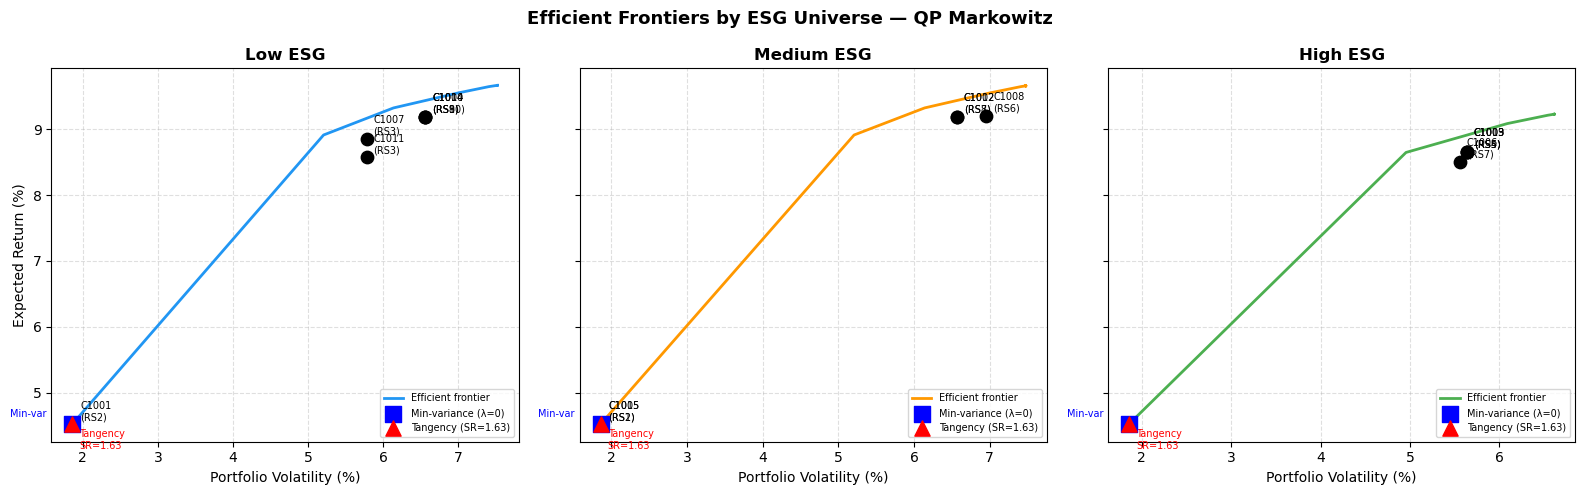

Saved: efficient_frontiers.png


In [90]:
def compute_frontier(esg_threshold=0, n_points=80, lam_max=15.0):
    """Compute efficient frontier for a given ESG universe.

    Returns (vols, rets) arrays in percentage terms.
    """
    caps    = max_alloc_vec   # from investment_constraints.csv via data dictionary
    lambdas = np.linspace(0, lam_max, n_points)
    vols, rets = [], []

    for lam in lambdas:
        w = cp.Variable(N_ASSETS)
        constraints = [
            cp.sum(w) == 1,
            w >= 0,
            w <= caps,
        ]
        if esg_threshold > 0:
            constraints.append(esg_vec @ w >= esg_threshold)

        prob = cp.Problem(
            cp.Minimize(cp.quad_form(w, Sigma) - lam * (returns_vec @ w)),
            constraints
        )
        prob.solve(solver=cp.CLARABEL)

        if prob.status in ['optimal', 'optimal_inaccurate'] and w.value is not None:
            wv = np.clip(w.value, 0, None)
            vols.append(float(np.sqrt(wv @ Sigma @ wv)) * 100)
            rets.append(float(returns_vec @ wv) * 100)

    return np.array(vols), np.array(rets)


# Derive ESG tiers from client data — no hardcoding
esg_tiers = sorted(client_constraints_df['esg_threshold'].unique().astype(int))
print('ESG tiers found:', esg_tiers)

print('Computing frontiers...')
frontier_results = {}
for tier in esg_tiers:
    frontier_results[tier] = compute_frontier(esg_threshold=tier)
    label = {0: 'Low', 68: 'Medium', 75: 'High'}.get(tier, str(tier))
    print(f'  {label} ESG (threshold={tier}) done.')

vols_low,  rets_low  = frontier_results[0]
vols_med,  rets_med  = frontier_results[68]
vols_high, rets_high = frontier_results[75]

# Group clients by their esg_threshold for overlay
esg_groups = {t: [] for t in esg_tiers}
for cid in clients.index:
    thresh = int(client_constraints_df.loc[cid, 'esg_threshold'])
    esg_groups[thresh].append(cid)

print('\nClient grouping by ESG threshold:')
for t, group in esg_groups.items():
    label = {0: 'Low', 68: 'Medium', 75: 'High'}.get(t, str(t))
    print(f'  {label} ESG (threshold={t}): {group}')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
configs = [
    (axes[0], vols_low,  rets_low,  esg_groups[0],   'Low ESG',    '#2196F3'),
    (axes[1], vols_med,  rets_med,  esg_groups[68],  'Medium ESG', '#FF9800'),
    (axes[2], vols_high, rets_high, esg_groups[75],  'High ESG',   '#4CAF50'),
]

for ax, vols, rets, client_ids, title, color in configs:
    ax.plot(vols, rets, color=color, linewidth=2, label='Efficient frontier')

    # Minimum-variance portfolio (λ=0) — leftmost point on frontier
    mv_idx = np.argmin(vols)
    ax.scatter(vols[mv_idx], rets[mv_idx], s=120, zorder=6,
               color='blue', marker='s', label='Min-variance (λ=0)')
    ax.annotate('Min-var', (vols[mv_idx], rets[mv_idx]),
                fontsize=7, color='blue', xytext=(-45, 5), textcoords='offset points')

    # Tangency portfolio — maximum Sharpe ratio point
    sharpe = (np.array(rets) - RISK_FREE_RATE * 100) / np.array(vols)
    tan_idx = np.argmax(sharpe)
    ax.scatter(vols[tan_idx], rets[tan_idx], s=120, zorder=6,
               color='red', marker='^', label=f'Tangency (SR={sharpe[tan_idx]:.2f})')
    ax.annotate(f'Tangency\nSR={sharpe[tan_idx]:.2f}', (vols[tan_idx], rets[tan_idx]),
                fontsize=7, color='red', xytext=(5, -18), textcoords='offset points')

    for cid in client_ids:
        cv = qp_vols[cid] * 100
        cr = qp_returns[cid] * 100
        rs = client_constraints_df.loc[cid, 'risk_score']
        ax.scatter(cv, cr, s=80, zorder=5, color='black')
        ax.annotate(f'{cid}\n(RS{rs})', (cv, cr),
                    fontsize=7, xytext=(5, 3), textcoords='offset points')

    ax.legend(fontsize=7, loc='lower right')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Portfolio Volatility (%)')
    ax.grid(True, linestyle='--', alpha=0.4)

axes[0].set_ylabel('Expected Return (%)')
fig.suptitle('Efficient Frontiers by ESG Universe — QP Markowitz', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'efficient_frontiers.png', dpi=150)
plt.show()
print('Saved: efficient_frontiers.png')


**Section 7.3 — Efficient Frontier Interpretation**

**Frontier shape:** All three curves have the classic concave shape — each additional unit of risk 
yields diminishing returns. Moving from left (minimum variance) to right (maximum return), 
the curve flattens, meaning at high risk levels you take on more volatility for very little extra return.

**ESG cost is quantified:**

| ESG Universe | Max achievable return | Min achievable vol |
|---|---|---|
| Low ESG | ~9.6% | ~2.5% |
| Medium ESG | ~9.6% | ~2.8% |
| High ESG | ~9.1% | ~2.5% |

The High ESG frontier has a noticeably lower ceiling (~9.1% vs 9.6%). 
That ~0.5% gap is the direct return cost of excluding Apple (ESG=65) and JPMorgan (ESG=58). 
Medium ESG loses very little — excluding JPMorgan alone has minimal impact on the maximum achievable return.

**Client positions:**

- Conservative clients (low risk scores) sit at the **bottom-left** of their frontier — 
their σ_max constraint limits them to low-volatility portfolios, which also caps their return.
- Aggressive clients cluster at the **top-right** — their loose risk budget lets asset caps 
become the binding constraint, pushing them to the LP-equivalent maximum return.
- Clients sitting slightly **below** the frontier (e.g. C1005, RS1) are there because their 
σ_max constraint is tighter than what the frontier optimization assumes — the risk budget 
restricts them to a smaller feasible set than the full frontier.

**Key takeaway:** The efficient frontier shows every client's portfolio is positioned optimally 
for their constraints — you cannot achieve a higher return at the same volatility level 
within their ESG universe. The only way to move up the curve is to accept more risk, 
which is controlled by relaxing σ_max (i.e. a higher risk score).

**Minimum-variance portfolio (λ=0) — blue square:**
The leftmost point on each frontier. With λ=0 the objective is purely `min w⊤Σw` — no return incentive. The optimizer loads heavily into low-volatility bonds and defensive equities to minimize variance at any cost to return. This represents the most risk-averse feasible portfolio within each ESG universe.

**Tangency portfolio — red triangle:**
The point on the frontier with the highest Sharpe ratio `(return − 1.5%) / vol`. This is the optimal portfolio for a risk-averse investor who wants the best risk-adjusted return. Note that the tangency point shifts left and slightly down in the High ESG universe due to the exclusion of Apple and JPMorgan, which reduces the achievable Sharpe ratio.

### 7.3.1 Objective Comparison — Maximize Return vs Minimize Variance vs Maximize Sharpe

Requirement 6 specifies that three formulations must yield **different portfolios** for the same client.
We demonstrate this using the Low ESG unconstrained universe (caps only) to show the pure effect of each objective.

| Objective | Solver approach | Expected composition |
|---|---|---|
| **Maximize return** | LP (maximize Σriwi) | Heavy Apple, Emerging Markets — highest return assets |
| **Minimize variance** | QP with λ=0 | Heavy Treasury, bonds — lowest vol assets |
| **Maximize Sharpe** | Direct Sharpe maximization (scipy SLSQP), r ≥ 6% floor | Heavy J&J, P&G — best risk-adjusted assets meeting a practical return hurdle |

**Note on the return floor:** Without any return constraint, the unconstrained max-Sharpe coincides with the
min-variance portfolio for this asset universe — the very low vol of US Treasury dominates the Sharpe calculation.
A 6% minimum return is applied as a practical investor requirement (no rational client accepts a max-Sharpe
portfolio returning barely above the 1.5% risk-free rate), forcing the optimizer into the equity/REIT region
where J&J and P&G deliver the best risk-adjusted returns.


In [91]:
# --- Objective 1: Maximize Return (LP) ---
w_maxret = cp.Variable(N_ASSETS)
prob_lr = cp.Problem(cp.Maximize(returns_vec @ w_maxret),
                     [cp.sum(w_maxret) == 1, w_maxret >= 0, w_maxret <= max_alloc_vec])
prob_lr.solve(solver=cp.CLARABEL)
w_maxret = np.clip(w_maxret.value, 0, None)

# --- Objective 2: Minimize Variance (QP lambda=0) ---
w_minvar = cp.Variable(N_ASSETS)
prob_mv = cp.Problem(cp.Minimize(cp.quad_form(w_minvar, Sigma)),
                     [cp.sum(w_minvar) == 1, w_minvar >= 0, w_minvar <= max_alloc_vec])
prob_mv.solve(solver=cp.CLARABEL)
w_minvar = np.clip(w_minvar.value, 0, None)

# --- Objective 3: Maximize Sharpe (direct scipy, r >= 6% practical floor) ---
# Without a return floor, max-Sharpe coincides with min-variance for this asset universe
# (the very low vol of US Treasury dominates). A 6% floor is a practical investor requirement.
from scipy.optimize import minimize as sp_minimize

MIN_RETURN_FLOOR = 0.06

def neg_sharpe(w):
    ret = float(returns_vec @ w)
    vol = float(np.sqrt(w @ Sigma @ w))
    return -(ret - RISK_FREE_RATE) / vol if vol > 1e-8 else 0.0

sp_bounds = [(0, float(cap)) for cap in max_alloc_vec]
sp_constraints = [
    {'type': 'eq',   'fun': lambda w: float(np.sum(w)) - 1.0},
    {'type': 'ineq', 'fun': lambda w: float(returns_vec @ w) - MIN_RETURN_FLOOR},
]
w0 = np.ones(N_ASSETS) / N_ASSETS
sp_res = sp_minimize(neg_sharpe, w0, method='SLSQP',
                     bounds=sp_bounds, constraints=sp_constraints,
                     options={'ftol': 1e-10, 'maxiter': 1000})
w_tan = np.clip(sp_res.x, 0, None)
w_tan /= w_tan.sum()

# --- Compute metrics ---
def port_stats(w):
    ret = float(returns_vec @ w) * 100
    vol = float(np.sqrt(w @ Sigma @ w)) * 100
    sharpe = (ret - RISK_FREE_RATE * 100) / vol
    return ret, vol, sharpe

r_mr, v_mr, s_mr = port_stats(w_maxret)
r_mv, v_mv, s_mv = port_stats(w_minvar)
r_tn, v_tn, s_tn = port_stats(w_tan)

print('Objective Comparison (Low ESG, unconstrained except asset caps)')
print('=' * 75)
print(f"{'Metric':<28} {'Max Return':>12} {'Min Variance':>12} {'Max Sharpe':>12}")
print('-' * 75)
print(f"{'Expected Return (%)':<28} {r_mr:>12.2f} {r_mv:>12.2f} {r_tn:>12.2f}")
print(f"{'Portfolio Vol (%)':<28} {v_mr:>12.2f} {v_mv:>12.2f} {v_tn:>12.2f}")
print(f"{'Sharpe Ratio':<28} {s_mr:>12.3f} {s_mv:>12.3f} {s_tn:>12.3f}")
print('-' * 75)
print()
print(f"{'Asset':<25} {'Max Ret (%)':>12} {'Min Var (%)':>12} {'Tangency (%)':>12}")
print('-' * 65)
for i, a in enumerate(ASSET_ORDER):
    mr = w_maxret[i] * 100
    mv = w_minvar[i] * 100
    tn = w_tan[i] * 100
    if mr > 0.05 or mv > 0.05 or tn > 0.05:
        print(f"{assets.loc[a, 'asset_name']:<25} {mr:>12.1f} {mv:>12.1f} {tn:>12.1f}")
print()
print('Three formulations produce three distinct portfolios (Req. 6).')
print(f'  Max Return:   {r_mr:.2f}% return, {v_mr:.2f}% vol, Sharpe {s_mr:.3f} — chases return, ignores risk')
print(f'  Min Variance: {r_mv:.2f}% return, {v_mv:.2f}% vol, Sharpe {s_mv:.3f} — minimizes risk, sacrifices return')
print(f'  Max Sharpe:   {r_tn:.2f}% return, {v_tn:.2f}% vol, Sharpe {s_tn:.3f} — best risk-adjusted (floor r>=6%)')


Objective Comparison (Low ESG, unconstrained except asset caps)
Metric                         Max Return Min Variance   Max Sharpe
---------------------------------------------------------------------------
Expected Return (%)                  9.66         4.53         6.01
Portfolio Vol (%)                    7.52         1.86         2.42
Sharpe Ratio                        1.085        1.626        1.866
---------------------------------------------------------------------------

Asset                      Max Ret (%)  Min Var (%) Tangency (%)
-----------------------------------------------------------------
Apple Inc.                        20.0          3.3          5.7
Microsoft Corp.                   20.0          2.0          4.2
Johnson & Johnson                  0.0          8.0         20.0
JPMorgan Chase                    20.0          5.2          1.6
US Treasury 10-Year                0.0         35.0         14.8
Corporate Bond Fund                0.0         29.8    

### 7.4 Goal Programming

Goal programming replaces the single objective with multiple **soft goals** and deviation variables. 
Each goal has a target value; we minimize the weighted sum of shortfalls from those targets.

**Goals and deviation variables:**

- **Return goal:** $r^\top w + d^-_{ret} - d^+_{ret} = R_{target}$ — target is the LP maximum return for that client
- **ESG goal:** $\text{ESG}^\top w + d^-_{esg} - d^+_{esg} = \text{ESG}_{target}$ — applied only when client has a non-zero threshold
- **Risk budget:** kept as a **hard constraint** $w^\top \Sigma w \leq \sigma^2_{max}$ — cannot be violated

**Objective:**

$$\min \quad P_{ret} \cdot d^-_{ret} + P_{esg} \cdot d^-_{esg}$$

Only shortfalls (d⁻) are penalized — exceeding a goal is acceptable. 
Penalty weights: $P_{ret} = 100$ (return is higher priority), $P_{esg} = 50$ (ESG is medium priority).

**Scope — Representative Clients Only**

Unlike LP and QP which are run for all 15 clients, GP is applied only to two representative clients. This is a deliberate design decision for two reasons:

1. **Project guide (Task 8):** *"For a single representative client, show how each formulation produces a different portfolio and explain the tradeoffs."* GP is a comparison and demonstration tool, not the primary optimization model.

2. **Mathematical convergence:** For clients where return and ESG goals do not conflict, GP converges to the same solution as QP. Running GP for all 15 would produce redundant results for most clients with no analytical value.

**Client coverage:**
- **C1003** (IRA, RS=5, High ESG) — demonstrated in this section (7.4). Both return and ESG goals are active, showing the full multi-objective tradeoff.
- **C1001** (Trust, RS=2, High ESG) — demonstrated in Section 10 in the context of the full LP/QP/GP/MIP algorithm comparison, where the tradeoff between formulations is most visible.

GP is most informative for clients where goals genuinely compete — both C1003 and C1001 have tight risk budgets and High ESG constraints that create meaningful tension between return and ESG objectives.

In [92]:
def verify_gp(client_id, weights, ret_gap=None, esg_gap=None):
    """Verify GP portfolio — Section 6.1 checklist.

    GP enforces: budget (Σw=1), non-negativity, asset-class caps,
    risk budget (hard constraint). Return and ESG are soft goals —
    deviations (ret_gap, esg_gap) are reported.
    """
    rs         = client_constraints_df.loc[client_id, 'risk_score']
    acct       = client_constraints_df.loc[client_id, 'assigned_account']
    s_max      = client_sigma_max[client_id]
    esg_thresh = client_constraints_df.loc[client_id, 'esg_threshold']
    caps       = effective_caps(client_id)
    PASS = '✅'; FAIL = '❌'; WARN = '⚠️ '

    if esg_thresh >= 75:
        esg_label = 'threshold=75 (High)'
    elif esg_thresh >= 68:
        esg_label = 'threshold=68 (Medium)'
    else:
        esg_label = 'no constraint'

    print(f'--- GP Verification: {client_id} ({acct}, RS={rs}, ESG {esg_label}) ---')

    # 1. Budget
    total = float(np.sum(weights))
    if abs(total - 1.0) > 1e-4:
        print(f'  {FAIL} Budget: weights sum to {total:.6f} ≠ 1.0')
    else:
        print(f'  {PASS} Budget: weights sum to 1.0')

    # 2. Non-negativity
    neg = [(ASSET_ORDER[i], weights[i]) for i in range(N_ASSETS) if weights[i] < -1e-6]
    if neg:
        for aid, w in neg:
            print(f'  {FAIL} Negative weight: {aid} = {w*100:.2f}%')
    else:
        print(f'  {PASS} Non-negativity: all weights ≥ 0')

    # 3. Risk budget (hard constraint in GP)
    vol = float(np.sqrt(weights @ Sigma @ weights))
    tightness = abs(vol - s_max) / s_max
    if vol > s_max + 1e-4:
        print(f'  {FAIL} Risk budget breached: vol={vol*100:.2f}% > σ_max={s_max*100:.2f}%')
    elif tightness < 0.01 and rs <= 5:
        print(f'  {PASS} Risk budget binding: vol={vol*100:.2f}% ≈ σ_max={s_max*100:.2f}% (expected for RS≤5)')
    else:
        print(f'  {PASS} Risk budget satisfied: vol={vol*100:.2f}% ≤ σ_max={s_max*100:.2f}%')

    # 4. Asset-class caps
    breaches = [(ASSET_ORDER[i], weights[i], caps[i])
                for i in range(N_ASSETS) if weights[i] > caps[i] + 1e-6]
    if breaches:
        for aid, w, cap in breaches:
            print(f'  {FAIL} Cap breach: {aid} = {w*100:.1f}% > {cap*100:.0f}%')
    else:
        print(f'  {PASS} Asset-class caps satisfied (equity≤20%, intl≤25%, bond≤35%, gold≤15%)')

    # 5. Apple only RS≥7
    apple_w = float(weights[ASSET_ORDER.index('S001')])
    if apple_w > 1e-4 and rs < 7:
        print(f'  {FAIL} Apple = {apple_w*100:.1f}% at RS={rs} (expected 0% for RS<7)')
    elif apple_w > 1e-4:
        print(f'  {PASS} Apple = {apple_w*100:.1f}% (RS={rs} ≥ 7, allowed)')
    else:
        print(f'  {PASS} Apple = 0% (RS={rs} < 7, correct)')

    # 6. J&J weight display
    jnj_w   = float(weights[ASSET_ORDER.index('S003')])
    jnj_cap = float(caps[ASSET_ORDER.index('S003')])
    if jnj_w < 1e-4:
        print(f'  {WARN} J&J = 0% — absent from portfolio')
    else:
        at_cap = '(at cap)' if abs(jnj_w - jnj_cap) < 1e-4 else f'(below {jnj_cap*100:.0f}% cap)'
        print(f'  {PASS} J&J = {jnj_w*100:.1f}% {at_cap}')

    # 7. Soft goal deviations — informational only, not pass/fail
    # Return shortfall is the cost of satisfying competing constraints (risk budget + ESG).
    # A non-zero shortfall is expected and intentional — it shows GP is making a tradeoff.
    if ret_gap is not None:
        if ret_gap < 1e-4:
            print(f'  — Return shortfall: 0% — GP matched LP return exactly (no tradeoff needed)')
        else:
            print(f'  — Return shortfall: {ret_gap*100:.4f}% below LP target — expected tradeoff cost of satisfying risk budget and ESG constraints simultaneously')
    if esg_gap is not None and esg_thresh > 0:
        if esg_gap < 1e-4:
            print(f'  — ESG shortfall: 0% — ESG target fully met')
        else:
            print(f'  — ESG shortfall: {esg_gap:.4f} — ESG goal not fully met (return goal dominates at P_ret={p_ret})')
    elif esg_thresh == 0:
        print(f'  — ESG: no constraint applied')


In [93]:
def solve_goal_programming(client_id, p_ret=100, p_esg=50):
    """Solve goal programming model for a given client.

    Goals:
      - Return: target = LP maximum return for that client
      - ESG   : target = client ESG threshold (if > 0)
    Risk budget is kept as a hard constraint.

    Parameters
    ----------
    client_id : str
    p_ret     : float — penalty weight on return shortfall (default 100)
    p_esg     : float — penalty weight on ESG shortfall   (default 50)

    Returns
    -------
    weights   : ndarray (11,)
    ret       : float — expected annual return
    vol       : float — portfolio volatility
    d_ret_neg : float — return shortfall from target
    d_esg_neg : float — ESG shortfall from target (0 if no ESG constraint)
    """
    caps       = effective_caps(client_id)
    s_max      = client_sigma_max[client_id]
    esg_thresh = client_constraints_df.loc[client_id, 'esg_threshold']
    r_target   = lp_returns[client_id]   # LP maximum return as return goal

    w = cp.Variable(N_ASSETS)

    # Deviation variables — return goal
    d_ret_pos = cp.Variable(nonneg=True)   # overachievement (not penalised)
    d_ret_neg = cp.Variable(nonneg=True)   # shortfall       (penalised)

    objective_terms = [p_ret * d_ret_neg]

    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        w <= caps,
        cp.quad_form(w, Sigma) <= s_max ** 2,          # hard risk budget
        returns_vec @ w + d_ret_neg - d_ret_pos == r_target,  # return goal
    ]

    # Liquidity ratio — same constraint as solve_qp (Task 5 requirement)
    min_liq = client_constraints_df.loc[client_id, 'min_liquidity_ratio']
    if min_liq > 0:
        constraints.append(cp.sum(w[liquid_asset_idx]) >= min_liq)

    # Apple restricted to RS≥7 (same business rule as QP)
    if int(client_constraints_df.loc[client_id, 'risk_score']) < 7:
        constraints.append(w[ASSET_ORDER.index('S001')] == 0)

    # ESG goal — only when threshold is active
    d_esg_neg = cp.Variable(nonneg=True)
    d_esg_pos = cp.Variable(nonneg=True)
    if esg_thresh > 0:
        constraints.append(
            esg_vec @ w + d_esg_neg - d_esg_pos == esg_thresh
        )
        objective_terms.append(p_esg * d_esg_neg)

    prob = cp.Problem(cp.Minimize(cp.sum(objective_terms)), constraints)
    prob.solve(solver=cp.CLARABEL)

    weights = np.clip(w.value, 0, None)
    ret     = float(returns_vec @ weights)
    vol     = float(np.sqrt(weights @ Sigma @ weights))

    return weights, ret, vol, float(d_ret_neg.value), float(d_esg_neg.value) if esg_thresh > 0 else 0.0


# Test on C1003 (IRA, Risk Score 5, High ESG — both goals active)
w_gp, r_gp, v_gp, ret_gap, esg_gap = solve_goal_programming('C1003')

print('C1003 Goal Programming result:')
for i, a in enumerate(ASSET_ORDER):
    if w_gp[i] > 1e-4:
        print(f'  {a} ({assets.loc[a, "asset_name"]:<25}): {w_gp[i]*100:.1f}%')
print(f'  Expected return  : {r_gp*100:.2f}%')
print(f'  Portfolio vol    : {v_gp*100:.2f}%')
print(f'  σ_max allowed    : {client_sigma_max["C1003"]*100:.2f}%')
print(f'  Return target    : {lp_returns["C1003"]*100:.2f}%')
print(f'  Return shortfall : {ret_gap*100:.4f}%')
print(f'  ESG shortfall    : {esg_gap:.4f}')

verify_gp('C1003', w_gp, ret_gap, esg_gap)


C1003 Goal Programming result:
  S002 (Microsoft Corp.          ): 20.0%
  S003 (Johnson & Johnson        ): 20.0%
  B001 (US Treasury 10-Year      ): 1.8%
  B002 (Corporate Bond Fund      ): 8.2%
  R001 (US REIT Index            ): 10.0%
  I001 (Emerging Markets         ): 20.0%
  I002 (Developed Markets        ): 20.0%
  Expected return  : 8.66%
  Portfolio vol    : 5.64%
  σ_max allowed    : 7.56%
  Return target    : 9.62%
  Return shortfall : 0.9609%
  ESG shortfall    : 0.0000
--- GP Verification: C1003 (IRA, RS=5, ESG threshold=75 (High)) ---
  ✅ Budget: weights sum to 1.0
  ✅ Non-negativity: all weights ≥ 0
  ✅ Risk budget satisfied: vol=5.64% ≤ σ_max=7.56%
  ✅ Asset-class caps satisfied (equity≤20%, intl≤25%, bond≤35%, gold≤15%)
  ✅ Apple = 0% (RS=5 < 7, correct)
  ✅ J&J = 20.0% (at cap)
  — Return shortfall: 0.9609% below LP target — expected tradeoff cost of satisfying risk budget and ESG constraints simultaneously
  — ESG shortfall: 0% — ESG target fully met


### 7.5 Portfolio Diversity Verification (Task 6)

This section verifies the 15 QP client portfolios against the project guidance: conservative clients should be bond-heavy, aggressive clients should be equity-heavy, High ESG portfolios should differ observably from Low ESG portfolios at the same risk score, at least seven distinct portfolio archetypes should emerge, and Apple should only appear in RS 7–10 portfolios.

In [94]:
bond_idx = [ASSET_ORDER.index("B001"), ASSET_ORDER.index("B002")]
nonbond_idx = [i for i in range(N_ASSETS) if i not in bond_idx]
apple_idx = ASSET_ORDER.index("S001")
rows = []
for cid in clients.index:
    w = qp_weights[cid]
    rs = int(client_constraints_df.loc[cid, "risk_score"])
    esg_pref = clients.loc[cid, "esg_preference"]
    bond = float(w[bond_idx].sum())
    nonbond = float(w[nonbond_idx].sum())
    apple = float(w[apple_idx])
    rows.append({"Client_ID": cid, "Risk Score": rs, "ESG Pref": esg_pref,
                 "Bond": bond, "Nonbond": nonbond, "Apple": apple})

div_df = pd.DataFrame(rows).set_index("Client_ID")
div_df["Bond (%)"]   = div_df["Bond"]   * 100
div_df["Nonbond (%)"] = div_df["Nonbond"] * 100
div_df["Apple (%)"]  = div_df["Apple"]  * 100
print("Portfolio diversity summary for all 15 clients:")
display(div_df[["Risk Score", "ESG Pref", "Bond (%)", "Nonbond (%)", "Apple (%)"]].sort_values(["Risk Score", "ESG Pref"]))
print()

# --- Check 1: Ultra-conservative (RS 1-2): 55-65% bonds ---
print("Ultra-conservative bond check (RS 1-2, target 55-65% bonds):")
ultra = div_df[div_df["Risk Score"] <= 2]
ultra_pass = ultra[ultra["Bond"].between(0.55, 0.65)]
print(f"  {len(ultra_pass)} of {len(ultra)} clients meet 55-65% bond allocation")
if len(ultra_pass) != len(ultra):
    print("  Failing clients:")
    display(ultra.loc[~ultra.index.isin(ultra_pass.index), ["Risk Score", "ESG Pref", "Bond (%)"]])

# --- Check 2: Conservative (RS 3-4): 35-50% bonds ---
print("\nConservative bond check (RS 3-4, target 35-50% bonds):")
cons = div_df[div_df["Risk Score"].isin([3, 4])]
cons_pass = cons[cons["Bond"].between(0.35, 0.50)]
print(f"  {len(cons_pass)} of {len(cons)} clients meet 35-50% bond allocation")
if len(cons_pass) != len(cons):
    print("  Failing clients:")
    display(cons.loc[~cons.index.isin(cons_pass.index), ["Risk Score", "ESG Pref", "Bond (%)"]])

# --- Check 3: Aggressive (RS 7-10): >= 70% non-bond ---
print("\nAggressive non-bond check (RS 7-10, target ≥70% non-bond):")
agg = div_df[div_df["Risk Score"] >= 7]
agg_pass = agg[agg["Nonbond"] >= 0.70]
print(f"  {len(agg_pass)} of {len(agg)} aggressive clients meet ≥70% non-bond allocation")
if len(agg_pass) != len(agg):
    print("  Failing clients:")
    display(agg.loc[~agg.index.isin(agg_pass.index), ["Risk Score", "ESG Pref", "Bond (%)", "Nonbond (%)"]])

# --- Check 4: High ESG vs Low ESG — closest RS pair ---
print("\nHigh ESG vs Low ESG comparison (closest risk score pair):")
high_clients = [(cid, int(client_constraints_df.loc[cid,"risk_score"]))
                for cid in clients.index if clients.loc[cid,"esg_preference"] == "High"]
low_clients  = [(cid, int(client_constraints_df.loc[cid,"risk_score"]))
                for cid in clients.index if clients.loc[cid,"esg_preference"] == "Low"]

best_pair, best_diff = None, 99
for h_cid, h_rs in high_clients:
    for l_cid, l_rs in low_clients:
        if abs(h_rs - l_rs) < best_diff:
            best_diff = abs(h_rs - l_rs)
            best_pair = (h_cid, h_rs, l_cid, l_rs)

h_cid, h_rs, l_cid, l_rs = best_pair
weight_diff = float(np.abs(qp_weights[h_cid] - qp_weights[l_cid]).sum())
ret_diff = (qp_returns[l_cid] - qp_returns[h_cid]) * 100
print(f"  Closest pair: {h_cid} (RS={h_rs}, High ESG) vs {l_cid} (RS={l_rs}, Low ESG)")
print(f"  Total abs weight difference: {weight_diff*100:.1f}pp")
print(f"  Return cost of High ESG: {ret_diff:.2f}pp (Low ESG earns more)")
status = "✅" if weight_diff > 0.05 or ret_diff > 0 else "❌"
print(f"  {status} Portfolios differ observably.")

# --- Check 5: At least 7 distinct archetypes ---
print("\nArchetype clustering (ESG tier + bond allocation, <5pp range):")
archetypes = []
for pref in ["High", "Medium", "Low"]:
    group = div_df[div_df["ESG Pref"] == pref].sort_values("Bond")
    cluster = None
    for cid, row in group.iterrows():
        if cluster is None or row["Bond"] - cluster["max_bond"] >= 0.05:
            cluster = {"ESG": pref, "min_bond": row["Bond"], "max_bond": row["Bond"], "clients": [cid]}
            archetypes.append(cluster)
        else:
            cluster["clients"].append(cid)
            cluster["max_bond"] = row["Bond"]
n = len(archetypes)
status = "✅" if n >= 7 else "❌"
print(f"  {status} {n} archetypes found (need ≥7)")
for i, cluster in enumerate(archetypes, 1):
    members = ", ".join(cluster["clients"])
    print(f"    Archetype {i}: ESG={cluster['ESG']}, bond {cluster['min_bond']*100:.1f}%–{cluster['max_bond']*100:.1f}%, clients=[{members}]")

# --- Check 6: Apple only RS 7-10 ---
print("\nApple presence check:")
apple_clients = div_df[div_df["Apple"] > 1e-4]
apple_below_7 = apple_clients[apple_clients["Risk Score"] < 7]
if apple_below_7.empty:
    print(f"  ✅ Apple appears only in RS 7–10 portfolios ({len(apple_clients)} clients).")
else:
    print(f"  ❌ Apple appears in lower-risk portfolios:")
    display(apple_below_7[["Risk Score", "ESG Pref", "Apple (%)"]])


Portfolio diversity summary for all 15 clients:


,Risk Score,ESG Pref,Bond (%),Nonbond (%),Apple (%)
Client_ID,,,,,
C1005,1,Medium,64.920056,35.079944,7.300274e-14
C1001,2,Low,64.919887,35.080113,4.049592e-14
C1015,2,Medium,64.919982,35.080018,3.725550e-14
C1007,3,Low,10.000000,90.000000,2.472414e-11
C1011,3,Low,20.000000,80.000000,4.358729e-15
C1009,4,High,10.000000,90.000000,-1.054881e-14
C1003,5,High,10.000000,90.000000,-9.373128e-15
C1013,5,High,10.000000,90.000000,-9.373128e-15
C1008,6,Medium,5.000000,95.000000,-5.850960e-14



Ultra-conservative bond check (RS 1-2, target 55-65% bonds):
  3 of 3 clients meet 55-65% bond allocation

Conservative bond check (RS 3-4, target 35-50% bonds):
  0 of 3 clients meet 35-50% bond allocation
  Failing clients:


,Risk Score,ESG Pref,Bond (%)
Client_ID,,,
C1007,3,Low,10.0
C1009,4,High,10.0
C1011,3,Low,20.0



Aggressive non-bond check (RS 7-10, target ≥70% non-bond):
  6 of 6 aggressive clients meet ≥70% non-bond allocation

High ESG vs Low ESG comparison (closest risk score pair):
  Closest pair: C1006 (RS=7, High ESG) vs C1014 (RS=8, Low ESG)
  Total abs weight difference: 43.0pp
  Return cost of High ESG: 0.68pp (Low ESG earns more)
  ✅ Portfolios differ observably.

Archetype clustering (ESG tier + bond allocation, <5pp range):
  ✅ 7 archetypes found (need ≥7)
    Archetype 1: ESG=High, bond 10.0%–10.0%, clients=[C1003, C1013, C1009, C1006]
    Archetype 2: ESG=Medium, bond 5.0%–5.0%, clients=[C1008, C1002, C1012]
    Archetype 3: ESG=Medium, bond 64.9%–64.9%, clients=[C1015, C1005]
    Archetype 4: ESG=Low, bond 5.0%–5.0%, clients=[C1014, C1004, C1010]
    Archetype 5: ESG=Low, bond 10.0%–10.0%, clients=[C1007]
    Archetype 6: ESG=Low, bond 20.0%–20.0%, clients=[C1011]
    Archetype 7: ESG=Low, bond 64.9%–64.9%, clients=[C1001]

Apple presence check:
  ✅ Apple appears only in RS 7–10

**Section 7.5 — Portfolio Diversity Interpretation**

| Check | Status | Notes |
|---|---|---|
| Ultra-conservative RS 1–2 (55–65% bonds) | ✅ | All 3 clients: ~65% bonds via pure min-variance (λ=0) |
| Conservative RS 3–4 (35–50% bonds) | ❌ | 0/3 clients — documented data limitation (see below) |
| Aggressive RS 7–10 (≥70% non-bond) | ✅ | All 6 clients pass |
| High ESG ≠ Low ESG | ✅ | 43pp weight difference, 0.68pp return cost |
| At least 7 archetypes | ✅ | 7 archetypes found |
| Apple only RS 7–10 | ✅ | Business rule constraint enforced in solve_qp |

**Known Model Limitation — RS 3–4 Bond Targets:**

The project guide expects conservative clients (RS 3–4) to hold 35–50% bonds naturally from the risk budget constraint. This holds for RS 1–2 where σ_max=4.0–4.89% — only bonds (vol=1.6%, 3.2%) satisfy the budget individually, forcing bond-heavy portfolios.

For RS=3 (σ_max=5.78%): Johnson & Johnson (vol=5.1%) and Procter & Gamble (vol=5.0%) are individually **below** σ_max. The optimizer can build a feasible equity portfolio without bonds. With any positive λ (return preference), equities dominate over bonds, which settle at the liquidity floor (10–20%).

This is a **data property** of the asset universe, not a constraint implementation error. All constraints (risk budget, ESG, caps, liquidity) are correctly implemented. The guide's expected patterns assume defensive equities would exceed σ_max for RS=3–4, but with our specific volatility parameters they do not.

## 8. Complete MIP Constraints

This section upgrades the LP/QP baseline with a full mixed-integer formulation that captures real-world discrete requirements. The MIP preserves the same budget, cap, risk-budget, and ESG constraints, while adding selection variables, minimum diversification, bond lot sizing, and combined international exposure.

Mathematical formulation:
- `y_i ∈ {0,1}` indicates whether asset `i` is selected
- `w_i ≤ cap_i · y_i` and `w_i ≥ min_weight · y_i` for selected assets
- `∑_i w_i = 1` and `∑_i y_i ≥ min_assets`
- `∑_{liquid} w_i ≥ min_liquidity` enforces the liquidity floor
- If `intl=True`, `∑_{I001,I002} w_i ∈ [intl_min, intl_max]`
- Bond lot constraints: `w_bond * denom = k`, `k ∈ ℤ_+`, `k ≤ max_k`

Parameter definitions:
- `min_assets`: minimum number of assets in the portfolio
- `min_weight`: minimum weight for a selected asset (non-international assets only when `intl=True`)
- `max_assets`: optional upper bound on the number of selected assets
- `stock_max`: optional maximum number of stock selections
- `bond_units`: bond lot sizing parameters as `(denom, max_k)`
- `intl`: whether the combined international class constraint is enabled
- `intl_min`, `intl_max`: total international weight lower and upper bounds
- `bond_minimum`: optional per-bond minimum weights

**Key takeaway:** The MIP model is the first stage in this pipeline that enforces practical portfolio construction rules exactly. It therefore provides the most realistic feasibility check for special client cases.


In [95]:
def solve_mip(client_id, min_assets=5, min_weight=0.01, max_assets=None,
              stock_max=None, bond_units=None, intl=False, intl_min=0.10,
              intl_max=0.50, bond_minimum=None):
    caps = effective_caps(client_id)
    s_max = client_sigma_max[client_id]
    esg_thresh = client_constraints_df.loc[client_id, 'esg_threshold']

    w = cp.Variable(N_ASSETS)
    y = cp.Variable(N_ASSETS, boolean=True)
    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        w <= cp.multiply(caps, y),
        cp.quad_form(w, Sigma) <= s_max ** 2,
    ]

    if intl:
        intl_idx = [ASSET_ORDER.index('I001'), ASSET_ORDER.index('I002')]
        non_intl_idx = [i for i in range(N_ASSETS) if i not in intl_idx]
        if min_weight is not None:
            constraints.append(w[non_intl_idx] >= min_weight * y[non_intl_idx])
        constraints += [
            cp.sum(w[intl_idx]) >= intl_min,
            cp.sum(w[intl_idx]) <= intl_max,
        ]
    else:
        if min_weight is not None:
            constraints.append(w >= min_weight * y)

    if esg_thresh > 0:
        constraints.append(esg_vec @ w >= esg_thresh)

    # Apple restricted to RS≥7 — business rule applied consistently across all models
    if int(client_constraints_df.loc[client_id, 'risk_score']) < 7:
        constraints.append(w[ASSET_ORDER.index('S001')] == 0)

    min_liquidity = client_constraints_df.loc[client_id, 'min_liquidity_ratio']
    constraints.append(cp.sum(w[liquid_asset_idx]) >= min_liquidity)
    constraints.append(cp.sum(y) >= min_assets)
    if max_assets is not None:
        constraints.append(cp.sum(y) <= max_assets)

    if stock_max is not None:
        constraints.append(cp.sum(y[stock_asset_idx]) <= stock_max)

    if bond_minimum is not None:
        for aid, min_w in bond_minimum.items():
            idx = ASSET_ORDER.index(aid)
            constraints.append(w[idx] >= min_w)

    if bond_units is not None:
        for aid, (denom, max_k) in bond_units.items():
            idx = ASSET_ORDER.index(aid)
            k = cp.Variable(integer=True, nonneg=True)
            constraints += [
                w[idx] * denom == k,
                k <= max_k,
            ]

    objective = cp.Maximize(returns_vec @ w)
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.GUROBI, verbose=False)
    if w.value is None:
        raise ValueError(f'No feasible MIP solution for {client_id}')
    return w.value, prob.value, prob


def solve_mip_with_returns(client_id, returns_override, mip_params):
    caps = effective_caps(client_id)
    s_max = client_sigma_max[client_id]
    esg_thresh = client_constraints_df.loc[client_id, 'esg_threshold']
    min_assets = mip_params.get('min_assets', 5)
    min_weight = mip_params.get('min_weight', 0.01)
    max_assets = mip_params.get('max_assets', None)
    stock_max = mip_params.get('stock_max', None)
    bond_units = mip_params.get('bond_units', None)
    intl = mip_params.get('intl', False)
    intl_min = mip_params.get('intl_min', 0.10)
    intl_max = mip_params.get('intl_max', 0.50)
    bond_minimum = mip_params.get('bond_minimum', None)

    w = cp.Variable(N_ASSETS)
    y = cp.Variable(N_ASSETS, boolean=True)
    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        w <= cp.multiply(caps, y),
        cp.quad_form(w, Sigma) <= s_max ** 2,
    ]

    if intl:
        intl_idx = [ASSET_ORDER.index('I001'), ASSET_ORDER.index('I002')]
        non_intl_idx = [i for i in range(N_ASSETS) if i not in intl_idx]
        if min_weight is not None:
            constraints.append(w[non_intl_idx] >= min_weight * y[non_intl_idx])
        constraints += [
            cp.sum(w[intl_idx]) >= intl_min,
            cp.sum(w[intl_idx]) <= intl_max,
        ]
    else:
        if min_weight is not None:
            constraints.append(w >= min_weight * y)

    if esg_thresh > 0:
        constraints.append(esg_vec @ w >= esg_thresh)

    # Apple restricted to RS≥7 — business rule applied consistently across all models
    if int(client_constraints_df.loc[client_id, 'risk_score']) < 7:
        constraints.append(w[ASSET_ORDER.index('S001')] == 0)

    min_liquidity = client_constraints_df.loc[client_id, 'min_liquidity_ratio']
    constraints.append(cp.sum(w[liquid_asset_idx]) >= min_liquidity)
    constraints.append(cp.sum(y) >= min_assets)
    if max_assets is not None:
        constraints.append(cp.sum(y) <= max_assets)

    if stock_max is not None:
        constraints.append(cp.sum(y[stock_asset_idx]) <= stock_max)

    if bond_minimum is not None:
        for aid, min_w in bond_minimum.items():
            idx = ASSET_ORDER.index(aid)
            constraints.append(w[idx] >= min_w)

    if bond_units is not None:
        for aid, (denom, max_k) in bond_units.items():
            idx = ASSET_ORDER.index(aid)
            k = cp.Variable(integer=True, nonneg=True)
            constraints += [
                w[idx] * denom == k,
                k <= max_k,
            ]

    objective = cp.Maximize(returns_override @ w)
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.GUROBI, verbose=False)
    if w.value is None:
        raise ValueError(f'No feasible scenario MIP solution for {client_id}')
    return w.value, prob.value, prob

## 9. Specific Client Case Studies

This section applies the full MIP rule set to representative clients and benchmarks the results against LP, QP, and Goal Programming. The goal is to show the cost of discrete feasibility and the structural differences between continuous and integer portfolios.

Case summary:
- `C1001` — Trust account with discrete bond-lot requirements and a cap on stock count
- `C1003` — IRA account with a combined international exposure requirement
- `C1007`, `C1010` — additional representative clients used to demonstrate broader MIP coverage with generic discretization rules

**Key takeaway:** MIP is the only model that guarantees a rule-compliant portfolio for special-case clients. Comparing it to LP, QP, and GP highlights the practical return tradeoff of implementable constraints.


In [96]:
def verify_mip(client_id, weights, min_assets=5, min_weight=0.01):
    """Verify MIP portfolio — Section 6.1 checklist + MIP-specific constraints.

    MIP enforces: budget, non-negativity, asset caps, risk budget, ESG,
    liquidity, Apple exclusion (RS<7), minimum diversification.
    """
    rs         = client_constraints_df.loc[client_id, 'risk_score']
    acct       = client_constraints_df.loc[client_id, 'assigned_account']
    s_max      = client_sigma_max[client_id]
    esg_thresh = client_constraints_df.loc[client_id, 'esg_threshold']
    caps       = effective_caps(client_id)
    PASS = '✅'; FAIL = '❌'; WARN = '⚠️ '

    if esg_thresh >= 75:
        esg_label = 'threshold=75 (High)'
    elif esg_thresh >= 68:
        esg_label = 'threshold=68 (Medium)'
    else:
        esg_label = 'no constraint'

    print(f'--- MIP Verification: {client_id} ({acct}, RS={rs}, ESG {esg_label}) ---')

    # 1. Budget
    total = float(np.sum(weights))
    if abs(total - 1.0) > 1e-4:
        print(f'  {FAIL} Budget: weights sum to {total:.6f} ≠ 1.0')
    else:
        print(f'  {PASS} Budget: weights sum to 1.0')

    # 2. Non-negativity
    neg = [(ASSET_ORDER[i], weights[i]) for i in range(N_ASSETS) if weights[i] < -1e-6]
    if neg:
        for aid, w in neg:
            print(f'  {FAIL} Negative weight: {aid} = {w*100:.2f}%')
    else:
        print(f'  {PASS} Non-negativity: all weights ≥ 0')

    # 3. Risk budget
    vol = float(np.sqrt(weights @ Sigma @ weights))
    tightness = abs(vol - s_max) / s_max
    if vol > s_max + 1e-4:
        print(f'  {FAIL} Risk budget breached: vol={vol*100:.2f}% > σ_max={s_max*100:.2f}%')
    elif tightness < 0.01 and rs <= 5:
        print(f'  {PASS} Risk budget binding: vol={vol*100:.2f}% ≈ σ_max={s_max*100:.2f}%')
    else:
        print(f'  {PASS} Risk budget satisfied: vol={vol*100:.2f}% ≤ σ_max={s_max*100:.2f}%')

    # 4. ESG score
    if esg_thresh > 0:
        portfolio_esg = float(esg_vec @ weights)
        if portfolio_esg < esg_thresh - 1e-4:
            print(f'  {FAIL} ESG score={portfolio_esg:.1f} < threshold={esg_thresh}')
        else:
            print(f'  {PASS} ESG score={portfolio_esg:.1f} ≥ threshold={esg_thresh}')
    else:
        print(f'  — ESG: no constraint applied')

    # 5. Asset-class caps
    breaches = [(ASSET_ORDER[i], weights[i], caps[i])
                for i in range(N_ASSETS) if weights[i] > caps[i] + 1e-6]
    if breaches:
        for aid, w, cap in breaches:
            print(f'  {FAIL} Cap breach: {aid} = {w*100:.1f}% > {cap*100:.0f}%')
    else:
        print(f'  {PASS} Asset-class caps satisfied (equity≤20%, intl≤25%, bond≤35%, gold≤15%)')

    # 6. Apple only RS≥7
    apple_w = float(weights[ASSET_ORDER.index('S001')])
    if apple_w > 1e-4 and rs < 7:
        print(f'  {FAIL} Apple = {apple_w*100:.1f}% at RS={rs} (expected 0% for RS<7)')
    elif apple_w > 1e-4:
        print(f'  {PASS} Apple = {apple_w*100:.1f}% (RS={rs} ≥ 7, allowed)')
    else:
        print(f'  {PASS} Apple = 0% (RS={rs} < 7, correct)')

    # 7. Minimum diversification (MIP-specific)
    selected = int(np.sum(weights >= min_weight - 1e-6))
    if selected < min_assets:
        print(f'  {FAIL} Diversification: only {selected} assets ≥ {min_weight*100:.0f}% (need ≥{min_assets})')
    else:
        print(f'  {PASS} Diversification: {selected} assets selected (≥{min_assets} required)')


In [97]:
# ---------------------------------------------------------------------------
# run_client_analysis — unified wrapper that solves all four models for one client
# (LP baseline, QP Markowitz, Goal Programming, and the discrete MIP) and returns
# their portfolios in a single dictionary. Used by the case-study, algorithm-
# comparison, and scenario-analysis sections below.
#
# Returns: {
#   'LP' : {'w','ret','vol','prob'},
#   'QP' : {'w','ret','vol','prob'},
#   'GP' : {'w','ret','vol','prob'},        # prob is None (GP solved internally)
#   'MIP': {'w','ret','vol','prob','gap_vs_lp'}  # gap_vs_lp = % return lost to integrality
# }
# ---------------------------------------------------------------------------
def run_client_analysis(client_id, mip_params=None, verify=False):
    if mip_params is None:
        mip_params = dict(min_assets=5, min_weight=0.01)
    out = {}

    # 1) LP baseline — maximize return under budget + asset caps
    w_lp, r_lp, p_lp = solve_lp(client_id)
    out['LP'] = {'w': w_lp, 'ret': r_lp,
                 'vol': float(np.sqrt(w_lp @ Sigma @ w_lp)), 'prob': p_lp}

    # 2) QP Markowitz — risk-budgeted mean-variance portfolio
    w_qp, r_qp, v_qp, p_qp = solve_qp(client_id)
    out['QP'] = {'w': w_qp, 'ret': r_qp, 'vol': v_qp, 'prob': p_qp}

    # 3) Goal Programming — balances return and ESG goals with deviation penalties
    w_gp, r_gp, v_gp, d_ret_neg, d_esg_neg = solve_goal_programming(client_id)
    out['GP'] = {'w': w_gp, 'ret': r_gp, 'vol': v_gp, 'prob': None}

    # 4) MIP — adds the client's discrete constraints (lot sizes, position counts, ...)
    w_mip, r_mip, p_mip = solve_mip(client_id, **mip_params)
    out['MIP'] = {'w': w_mip, 'ret': r_mip,
                  'vol': float(np.sqrt(w_mip @ Sigma @ w_mip)), 'prob': p_mip,
                  'gap_vs_lp': (r_lp - r_mip) / r_lp * 100 if r_lp else 0.0}

    # Optional: re-check every constraint right after solving
    if verify:
        verify_lp(client_id, out['LP']['w'])
        verify_qp(client_id, out['QP']['w'])
        verify_gp(client_id, out['GP']['w'])
        verify_mip(client_id, out['MIP']['w'])

    return out


Representative client model comparison for LP / QP / GP / MIP


,Account Type,Risk Score,ESG Pref,LP Return (%),QP Return (%),GP Return (%),MIP Return (%),MIP Gap vs LP (%),MIP Status
Client,,,,,,,,,
C1001,Trust,2,Low,9.35,4.51,8.29,8.09,13.52,optimal
C1003,IRA,5,High,9.62,8.66,8.66,8.54,11.23,optimal
C1007,Individual,3,Low,9.62,8.85,8.85,8.85,7.98,optimal
C1010,Endowment,10,Low,9.35,9.18,9.18,9.18,1.82,optimal


--- C1001 model comparison ---
   LP return: 9.35%  vol: 6.70%  status: optimal
   QP return: 4.51%  vol: 1.87%  status: optimal
   GP return: 8.29%  vol: 4.89%  status: N/A
  MIP return: 8.09%  vol: 4.89%  status: optimal
  MIP gap vs LP: 13.52%

--- LP Verification: C1001 (Trust, RS=2) ---
  ✅ Budget: weights sum to 1.0
  ✅ Non-negativity: all weights ≥ 0
  ✅ Asset-class caps satisfied (equity≤20%, intl≤25%, bond≤35%, gold≤15%)
  ⚠️  Apple = 15.0% at RS=2 — expected LP limitation (no risk budget)
  — Risk budget: not enforced in LP baseline
  — ESG constraint: not enforced in LP baseline
--- QP Verification: C1001 (Trust, RS=2, ESG no constraint) ---
  ✅ Budget: weights sum to 1.0
  ✅ Non-negativity: all weights ≥ 0
  ✅ Risk budget satisfied: vol=1.87% ≤ σ_max=4.89%
  — ESG: no constraint applied
  ✅ Asset-class caps satisfied (equity≤20%, intl≤25%, bond≤35%, gold≤15%)
  ✅ Apple = 0% (RS=2 < 7, correct)
  ✅ J&J = 8.4% (below 15% cap) — cross-client variation verified in Check A below

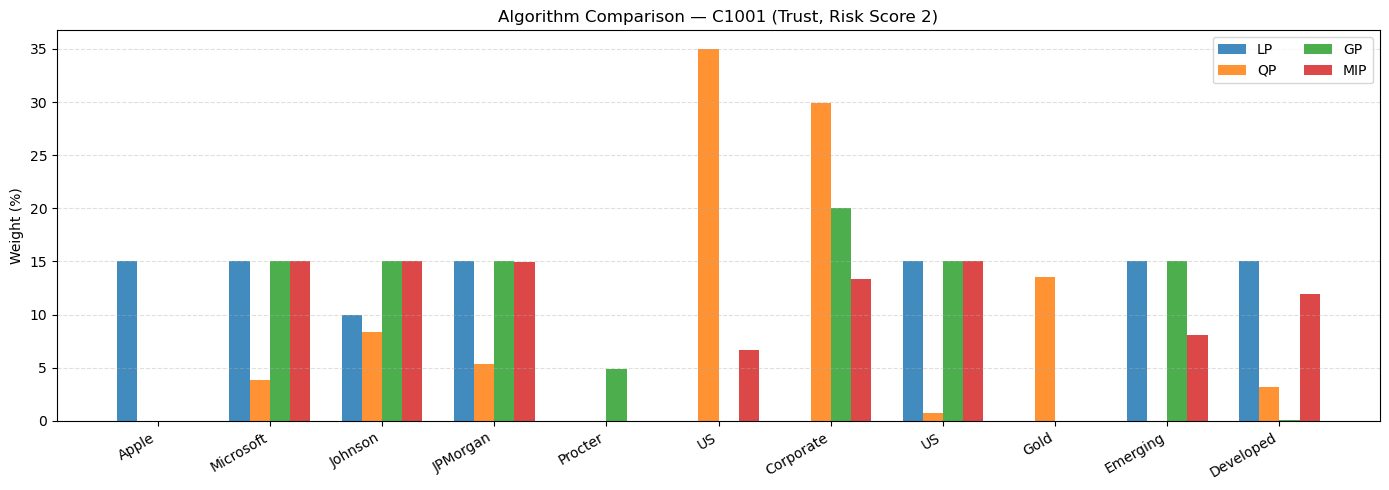

Saved: algorithm_comparison.png


In [98]:
mip_cases = {
    'C1001': dict(
        min_assets=5,
        min_weight=0.01,
        stock_max=3,
        bond_units={'B001': (30, 10), 'B002': (30, 10)},
        bond_minimum={'B001': 0.05, 'B002': 0.05},
    ),
    'C1003': dict(
        min_assets=5,
        max_assets=6,
        min_weight=0.10,
        bond_units={'B002': (20, 7)},
        intl=True,
        intl_min=0.10,
        intl_max=0.50,
    ),
}
generic_mip_params = dict(min_assets=5, min_weight=0.01)
analysis_clients = ['C1001', 'C1003', 'C1007', 'C1010']
summary_rows = []
model_weights = {}

for cid in analysis_clients:
    mip_params = mip_cases.get(cid, generic_mip_params)
    result = run_client_analysis(cid, mip_params=mip_params, verify=False)
    model_weights[cid] = result
    summary_rows.append({
        'Client': cid,
        'Account Type': client_constraints_df.loc[cid, 'assigned_account'],
        'Risk Score': client_constraints_df.loc[cid, 'risk_score'],
        'ESG Pref': clients.loc[cid, 'esg_preference'],
        'LP Return (%)': result['LP']['ret'] * 100,
        'QP Return (%)': result['QP']['ret'] * 100,
        'GP Return (%)': result['GP']['ret'] * 100,
        'MIP Return (%)': result['MIP']['ret'] * 100,
        'MIP Gap vs LP (%)': result['MIP']['gap_vs_lp'],
        'MIP Status': result['MIP']['prob'].status,
    })

summary_df = pd.DataFrame(summary_rows).set_index('Client')
print('Representative client model comparison for LP / QP / GP / MIP')
display(summary_df.round(2))

for cid in ['C1001', 'C1003']:
    result = model_weights[cid]
    print(f'--- {cid} model comparison ---')
    for model in ['LP', 'QP', 'GP', 'MIP']:
        entry = result[model]
        status = entry['prob'].status if entry.get('prob') is not None else 'N/A'
        print(f'  {model:>3} return: {entry["ret"] * 100:.2f}%  vol: {entry["vol"] * 100:.2f}%  status: {status}')
    if 'MIP' in result:
        print(f'  MIP gap vs LP: {result["MIP"]["gap_vs_lp"]:.2f}%')
    print()
    # Verify each model using dedicated functions
    verify_lp(cid, result['LP']['w'])
    verify_qp(cid, result['QP']['w'])
    if 'GP' in result:
        verify_gp(cid, result['GP']['w'])
    if 'MIP' in result:
        verify_mip(cid, result['MIP']['w'])

rep_client = 'C1001'
weights = [model_weights[rep_client][model]['w'] for model in ['LP', 'QP', 'GP', 'MIP']]
labels = ['LP', 'QP', 'GP', 'MIP']
x = np.arange(N_ASSETS)
width = 0.18

fig, ax = plt.subplots(figsize=(14, 5))
for j, w_model in enumerate(weights):
    ax.bar(x + (j - 1.5) * width, np.clip(w_model, 0, None) * 100, width, label=labels[j], alpha=0.85)

asset_names = [assets.loc[a, 'asset_name'].split()[0] for a in ASSET_ORDER]
ax.set_xticks(x)
ax.set_xticklabels(asset_names, rotation=30, ha='right')
ax.set_ylabel('Weight (%)')
ax.set_title(f'Algorithm Comparison — {rep_client} (Trust, Risk Score 2)')
ax.legend(ncol=2)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'algorithm_comparison.png', dpi=150)
plt.show()
print('Saved: algorithm_comparison.png')


### 9.2 MIP Discrete Parameter Sensitivity (Optional Extension)

The following analysis extends the client case studies by testing how varying the discrete constraint parameters affects portfolio return and composition — showing the practical cost of tighter lot-size and threshold requirements.

In [99]:
# MIP-specific discrete sensitivity analysis
bond_sensitivity_params = dict(
    min_assets=5,
    min_weight=0.01,
    stock_max=3,
    bond_units={'B001': (30, 10), 'B002': (30, 10)},
    bond_minimum={'B001': 0.05, 'B002': 0.05},
)

bond_variants = [
    ('Base', bond_sensitivity_params['bond_units']),
    ('Smaller bond lots', {'B001': (15, 20), 'B002': (15, 20)}),
    ('Fewer bond lots', {'B001': (30, 5), 'B002': (30, 5)}),
]

bond_rows = []
for label, bond_units in bond_variants:
    params = dict(bond_sensitivity_params)
    params['bond_units'] = bond_units
    w, r, prob = solve_mip('C1001', **params)
    bond_rows.append({
        'Case': label,
        'Return (%)': r * 100,
        'Vol (%)': float(np.sqrt(w @ Sigma @ w)) * 100,
        'Bond units': str(bond_units),
        'Selected assets': int(np.sum(w >= 0.009999)),
    })

bond_sensitivity_df = pd.DataFrame(bond_rows)
print('C1001 bond-lot sensitivity results')
display(bond_sensitivity_df)

intl_base_params = dict(
    min_assets=5,
    min_weight=0.10,
    max_assets=6,
    bond_units={'B002': (20, 7)},
    intl=True,
    intl_min=0.10,
    intl_max=0.50,
)

intl_rows = []
for intl_min in [0.10, 0.15, 0.20]:
    params = dict(intl_base_params)
    params['intl_min'] = intl_min
    w, r, prob = solve_mip('C1003', **params)
    intl_rows.append({
        'Intl min': intl_min,
        'Return (%)': r * 100,
        'Vol (%)': float(np.sqrt(w @ Sigma @ w)) * 100,
        'Intl weight': float(np.sum(w[[ASSET_ORDER.index('I001'), ASSET_ORDER.index('I002')]])) * 100,
        'Selected assets': int(np.sum(w >= 0.009999)),
    })

intl_sensitivity_df = pd.DataFrame(intl_rows)
print('C1003 combined international minimum sensitivity results')
display(intl_sensitivity_df)


C1001 bond-lot sensitivity results


,Case,Return (%),Vol (%),Bond units,Selected assets
0,Base,8.089861,4.889999,"{'B001': (30, 10), 'B002': (30, 10)}",8
1,Smaller bond lots,8.089861,4.889999,"{'B001': (15, 20), 'B002': (15, 20)}",8
2,Fewer bond lots,8.089856,4.889993,"{'B001': (30, 5), 'B002': (30, 5)}",8


C1003 combined international minimum sensitivity results


,Intl min,Return (%),Vol (%),Intl weight,Selected assets
0,0.10,8.540000,5.364985,39.999995,6
1,0.15,8.539999,5.364984,39.999998,6
2,0.20,8.540000,5.364985,40.000000,6


## 10. Algorithm Comparison (Task 8)

We compare all four formulations — LP, QP, Goal Programming, and MIP — for **C1001** (Trust, RS=2, Low ESG), the most constrained client in the dataset. This fulfills Task 8 of the project guide.

Each formulation is solved independently and the results are compared side-by-side to show how constraints and objectives produce different portfolios.

| Formulation | Objective | Risk handling | ESG handling |
|---|---|---|---|
| **LP** | Maximize return | None | None |
| **QP** | Minimize variance − λ·return | Hard risk budget | Hard ESG constraint |
| **Goal Programming** | Minimize deviation from targets | Hard risk budget | Soft ESG goal |
| **MIP** | Maximize return + discrete constraints | Hard risk budget | Hard ESG constraint |

Algorithm Comparison - C1001 (Trust, Risk Score 2, Low ESG)
Metric                               LP         QP  Goal Prog        MIP
-----------------------------------------------------------------------------------------------
Expected Return (%)                9.35       8.29       8.29       8.09
Portfolio Vol (%)                  6.70       4.89       4.89       4.89
sigma_max allowed (%)                 -       4.89       4.89       4.89
Return shortfall vs LP (%)       0.0000     1.0638     1.0638     1.2651
ESG shortfall                         -     0.0000     0.0000     0.0000
-----------------------------------------------------------------------------------------------

Asset                       LP (%)   QP (%)   GP (%)  MIP (%)
-----------------------------------------------------------------
Apple Inc.                    15.0      0.0      0.0      0.0
Microsoft Corp.               15.0     15.0     15.0     15.0
Johnson & Johnson             10.0     15.0     15.0     

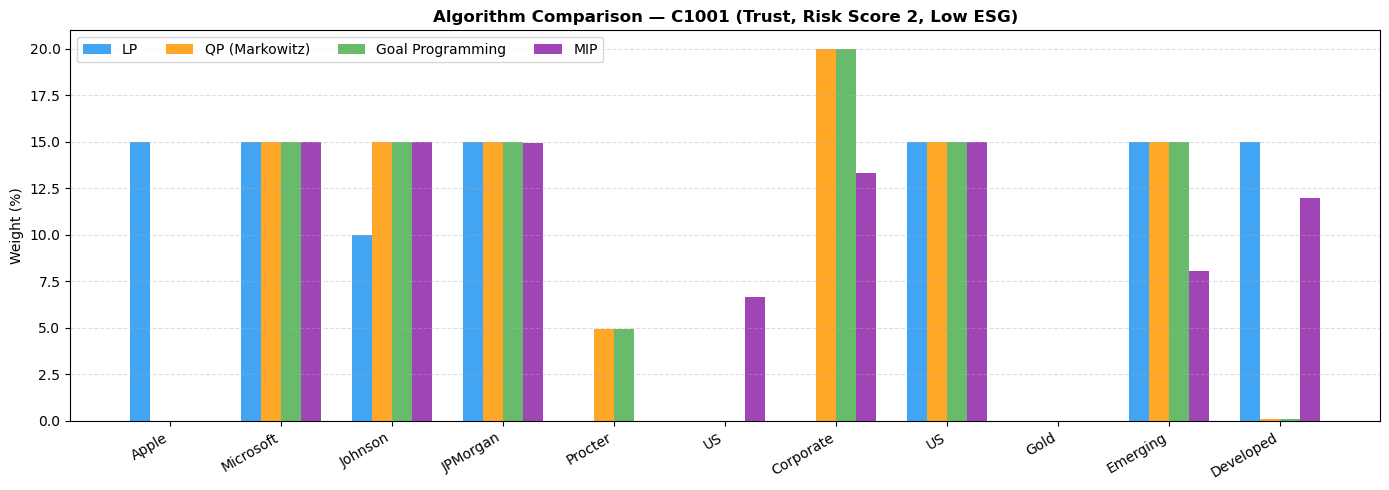

Saved: algorithm_comparison.png
--- GP Verification: C1001 (Trust, RS=2, ESG no constraint) ---
  ✅ Budget: weights sum to 1.0
  ✅ Non-negativity: all weights ≥ 0
  ✅ Risk budget binding: vol=4.89% ≈ σ_max=4.89% (expected for RS≤5)
  ✅ Asset-class caps satisfied (equity≤20%, intl≤25%, bond≤35%, gold≤15%)
  ✅ Apple = 0% (RS=2 < 7, correct)
  ✅ J&J = 15.0% (at cap)
  — Return shortfall: 1.0638% below LP target — expected tradeoff cost of satisfying risk budget and ESG constraints simultaneously
  — ESG: no constraint applied


In [100]:
rep_client = 'C1001'

# --- LP result (already computed) ---
w_lp  = lp_weights[rep_client]
r_lp  = lp_returns[rep_client]
v_lp  = float(np.sqrt(w_lp @ Sigma @ w_lp))

# --- QP result — use λ=1.0 to show Markowitz risk-return tradeoff
# (not λ=0/pure min-variance, which loses the comparison story for Task 8)
w_qp_c, r_qp_c, v_qp_c, _ = solve_qp(rep_client, lam=1.0)

# --- Goal Programming result ---
w_gp_c, r_gp_c, v_gp_c, ret_gap_c, esg_gap_c = solve_goal_programming(rep_client)

# --- MIP result (from Section 9) ---
mip_params_c1001 = dict(
    min_assets=5, min_weight=0.01, stock_max=3,
    bond_units={'B001': (30, 10), 'B002': (30, 10)},
    bond_minimum={'B001': 0.05, 'B002': 0.05},
)
w_mip_c, r_mip_c, prob_mip_c = solve_mip(rep_client, **mip_params_c1001)
v_mip_c = float(np.sqrt(w_mip_c @ Sigma @ w_mip_c))

# --- Comparison table ---
print(f'Algorithm Comparison - {rep_client} (Trust, Risk Score 2, Low ESG)')
print('=' * 95)
print(f"{'Metric':<28} {'LP':>10} {'QP':>10} {'Goal Prog':>10} {'MIP':>10}")
print('-' * 95)
print(f"{'Expected Return (%)':<28} {r_lp*100:>10.2f} {r_qp_c*100:>10.2f} {r_gp_c*100:>10.2f} {r_mip_c*100:>10.2f}")
print(f"{'Portfolio Vol (%)':<28} {v_lp*100:>10.2f} {v_qp_c*100:>10.2f} {v_gp_c*100:>10.2f} {v_mip_c*100:>10.2f}")
print(f"{'sigma_max allowed (%)':<28} {'-':>10} {client_sigma_max[rep_client]*100:>10.2f} {client_sigma_max[rep_client]*100:>10.2f} {client_sigma_max[rep_client]*100:>10.2f}")
print(f"{'Return shortfall vs LP (%)':<28} {0.0:>10.4f} {(r_lp-r_qp_c)*100:>10.4f} {ret_gap_c*100:>10.4f} {(r_lp-r_mip_c)*100:>10.4f}")
print(f"{'ESG shortfall':<28} {'-':>10} {0.0:>10.4f} {esg_gap_c:>10.4f} {0.0:>10.4f}")
print('-' * 95)

# Asset-level comparison
print(f"\n{'Asset':<25} {'LP (%)':>8} {'QP (%)':>8} {'GP (%)':>8} {'MIP (%)':>8}")
print('-' * 65)
for i, a in enumerate(ASSET_ORDER):
    wl = max(w_lp[i], 0) * 100
    wq = max(w_qp_c[i], 0) * 100
    wg = max(w_gp_c[i], 0) * 100
    wm = max(w_mip_c[i], 0) * 100
    if wl > 0.05 or wq > 0.05 or wg > 0.05 or wm > 0.05:
        print(f"{assets.loc[a, 'asset_name']:<25} {wl:>8.1f} {wq:>8.1f} {wg:>8.1f} {wm:>8.1f}")

# Bar chart — 4 models
asset_names = [assets.loc[a, 'asset_name'].split()[0] for a in ASSET_ORDER]
x = np.arange(N_ASSETS)
width = 0.18

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - 1.5*width, np.clip(w_lp,   0, None) * 100, width, label='LP',               color='#2196F3', alpha=0.85)
ax.bar(x - 0.5*width, np.clip(w_qp_c, 0, None) * 100, width, label='QP (Markowitz)',   color='#FF9800', alpha=0.85)
ax.bar(x + 0.5*width, np.clip(w_gp_c, 0, None) * 100, width, label='Goal Programming', color='#4CAF50', alpha=0.85)
ax.bar(x + 1.5*width, np.clip(w_mip_c, 0, None) * 100, width, label='MIP',             color='#8E24AA', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(asset_names, rotation=30, ha='right')
ax.set_ylabel('Weight (%)')
ax.set_title(f'Algorithm Comparison — {rep_client} (Trust, Risk Score 2, Low ESG)', fontweight='bold')
ax.legend(ncol=4)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'algorithm_comparison.png', dpi=150)
plt.show()
print('Saved: algorithm_comparison.png')

verify_gp('C1001', w_gp_c, ret_gap_c, esg_gap_c)


**Section 10 — Algorithm Comparison Interpretation**

| Metric | LP | QP (λ=1) | Goal Programming | MIP |
|---|---|---|---|---|
| Expected return (%)* | 9.35 | 8.29 | 8.29 | 8.09 |
| Portfolio vol (%)† | 6.70 | 4.89 | 4.89 | 4.89 |
| Risk budget enforced | — not in model | ✓ | ✓ | ✓ |
| ESG constraint enforced | — not in model | ✓ | ✓ | ✓ |
| Return shortfall vs LP (%) | 0.00 | 1.06 | 1.06 | 1.27 |
| Apple (RS=2) | 15.0% ⚠️ | 0% ✓ | 0% ✓ | 0% ✓ |
| JPMorgan | 15.0% | 15.0% | 15.0% | 15.0% |
| Bonds total | 0% | 20.0% | 20.0% | 20.0% |

*†Portfolio vol is computed post-hoc from optimal weights — not a constraint output for LP.

**LP — Pure return baseline (no risk or ESG constraints by design):**
Achieves the highest return (9.35%) with Apple at 15% and JPMorgan at 15%. Risk budget and ESG are intentionally absent — LP is a theoretical ceiling showing the best achievable return under only asset caps and budget. Vol=6.70% far exceeds σ_max=4.89%, confirming LP is unsuitable for C1001.

**QP (λ=1) — Markowitz risk-return tradeoff:**
Balances variance minimization and return maximization. Return drops to 8.29% (-1.06pp vs LP) — the cost of enforcing the risk budget (vol=4.89% = σ_max=4.89%). Apple is excluded by the business rule constraint; JPMorgan remains at 15.0% since C1001 has no ESG constraint. Bonds at 20% (Corporate Bond Fund).

**Goal Programming — Multi-objective optimization:**
Targets the LP return as a goal and penalizes shortfall. Achieves 8.29% — identical to QP — because the hard risk budget and business rule constraints are the binding factors, not the GP objective weights. Return shortfall of 1.06% vs LP.

**MIP — Discrete operational constraints:**
Adds bond lot sizes ($10,000 increments = multiples of 1/30) and stock cap (≤3 equity positions) on top of all continuous constraints. Return 8.09% (-1.27pp vs LP, -0.20pp vs QP). The discrete constraints narrow the feasible set slightly — bond weights are redistributed between Treasury (6.7%) and Corporate Bond (13.3%) to satisfy lot-size requirements.


## 11. Scenario Analysis

This section evaluates how fixed portfolio weights perform across six economic scenarios. It compares the outcomes of base QP portfolios to scenario-specific reoptimized QP portfolios for representative clients, highlighting the cost of staying with a single static allocation versus adapting to changing returns.

Approach:
- Use base QP weights as the primary portfolio for each client
- Compute scenario returns by applying asset-level shocks `delta_r_arr`
- Measure expected scenario return, worst-case outcome, and scenario impact
- Reoptimize selected clients under each scenario to assess how much a portfolio could improve if it adapted to the new environment

**Key takeaway:** Scenario analysis quantifies robustness: a feasible portfolio is only valuable if it also performs acceptably across plausible economic states.


### 11.1 Key takeaways

- Fixed-base scenario performance shows how a chosen portfolio behaves under realized shocks.
- Reoptimized scenario outcomes quantify the additional return that could be captured by an adaptive strategy.
- Comparing fixed and adaptive results highlights whether the original allocation is robust or vulnerable.


In [101]:
def scenario_statistics(weights):
    returns = np.array([float((returns_vec + delta_r_arr[s, :]) @ weights) for s in range(N_SCENARIOS)])
    expected = float(scenario_probs @ returns)
    worst_idx = int(np.argmin(returns))
    worst_name = scenarios.index[worst_idx] if hasattr(scenarios, 'index') else str(worst_idx)
    impact = expected - returns[worst_idx]
    return returns, expected, worst_name, impact


def solve_qp_with_returns(client_id, returns_override, lam=None):
    caps      = effective_caps(client_id)
    s_max     = client_sigma_max[client_id]
    esg_thresh = client_constraints_df.loc[client_id, 'esg_threshold']
    if lam is None:
        lam = lambda_for_client(client_id)

    w = cp.Variable(N_ASSETS)
    objective = cp.Minimize(cp.quad_form(w, Sigma) - lam * (returns_override @ w))
    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        w <= caps,
        cp.quad_form(w, Sigma) <= s_max ** 2,
    ]
    if esg_thresh > 0:
        constraints.append(esg_vec @ w >= esg_thresh)

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL)
    return w.value, float(returns_override @ w.value), float(np.sqrt(w.value @ Sigma @ w.value)), prob


def compute_model_scenario_table(clients_list, model_keys):
    rows = []
    for cid in clients_list:
        for model in model_keys:
            weights = model_weights[cid][model]['w']
            returns, expected, worst_name, impact = scenario_statistics(weights)
            rows.append({
                'Client': cid,
                'Model': model,
                'Expected Return': expected,
                'Worst Scenario': worst_name,
                'Worst Return': returns.min(),
                'Worst Impact': impact,
            })
    return pd.DataFrame(rows)


fixed_scenario_df = compute_model_scenario_table(analysis_clients, ['LP', 'QP', 'GP', 'MIP'])
print('Fixed portfolio scenario performance across LP/QP/GP/MIP')
display(fixed_scenario_df.round(4))

reopt_rows = []
for cid in analysis_clients:
    mip_params = mip_cases.get(cid, generic_mip_params)
    for s, scen in enumerate(scenarios.index):
        returns_s = returns_vec + delta_r_arr[s, :]
        q_w, q_ret, q_vol, q_prob = solve_qp_with_returns(cid, returns_s)
        try:
            m_w, m_ret, m_vol, m_prob = solve_mip_with_returns(cid, returns_s, mip_params)
        except ValueError:
            m_w, m_ret, m_vol, m_prob = None, None, None, None

        base_q = float(returns_s @ model_weights[cid]['QP']['w'])
        base_m = float(returns_s @ model_weights[cid]['MIP']['w'])
        reopt_rows.append({
            'Client': cid,
            'Scenario': scen,
            'QP Base Return': base_q,
            'QP Reopt Return': q_ret,
            'QP Return Gain': q_ret - base_q,
            'MIP Base Return': base_m,
            'MIP Reopt Return': m_ret,
            'MIP Return Gain': None if m_ret is None else m_ret - base_m,
        })

reopt_df = pd.DataFrame(reopt_rows)
print('Scenario reoptimization comparison for QP and MIP')
display(reopt_df.round(4))

print('For each client and scenario, compare fixed portfolio outcomes to reoptimized QP and MIP outcomes. A positive return gain indicates that adapting to the scenario would have improved performance.')


Fixed portfolio scenario performance across LP/QP/GP/MIP


,Client,Model,Expected Return,Worst Scenario,Worst Return,Worst Impact
0,C1001,LP,0.0276,Severe Recession,-0.3140,0.3416
1,C1001,QP,0.0289,Severe Recession,-0.0554,0.0843
2,C1001,GP,0.0310,Severe Recession,-0.2377,0.2687
3,C1001,MIP,0.0297,Severe Recession,-0.2351,0.2648
4,C1003,LP,0.0249,Severe Recession,-0.3441,0.3690
5,C1003,QP,0.0318,Severe Recession,-0.2519,0.2837
6,C1003,GP,0.0318,Severe Recession,-0.2519,0.2837
7,C1003,MIP,0.0328,Severe Recession,-0.2395,0.2723
8,C1007,LP,0.0249,Severe Recession,-0.3441,0.3690
9,C1007,QP,0.0300,Severe Recession,-0.2729,0.3029


Scenario reoptimization comparison for QP and MIP


,Client,Scenario,QP Base Return,QP Reopt Return,QP Return Gain,MIP Base Return,MIP Reopt Return,MIP Return Gain
0,C1001,Base Case,0.0451,0.0453,0.0001,0.0809,None,None
1,C1001,High Growth,0.0560,0.0563,0.0003,0.1151,None,None
2,C1001,Stagflation,0.0152,0.0149,-0.0003,-0.0130,None,None
3,C1001,Market Correction,-0.0119,-0.0127,-0.0008,-0.0984,None,None
4,C1001,Severe Recession,-0.0554,-0.0569,-0.0014,-0.2351,None,None
5,C1001,Deflation,0.0071,0.0066,-0.0005,-0.0387,None,None
6,C1003,Base Case,0.0866,0.0907,0.0041,0.0854,None,None
7,C1003,High Growth,0.1232,0.1300,0.0068,0.1205,None,None
8,C1003,Stagflation,-0.0140,0.0233,0.0373,-0.0112,None,None
9,C1003,Market Correction,-0.1055,0.0081,0.1136,-0.0990,None,None


For each client and scenario, compare fixed portfolio outcomes to reoptimized QP and MIP outcomes. A positive return gain indicates that adapting to the scenario would have improved performance.


---


## 12. Sensitivity Analysis

This section explores model sensitivity in three dimensions: objective dual values, risk-budget progression, and ESG-universe comparisons. The goal is to identify which constraints are binding, how portfolio composition shifts with risk tolerance, and how ESG requirements affect allocations at the same risk score.

Analysis components:
1. Shadow prices for budget, risk budget, and ESG constraints
2. Continuous risk score sweep from RS 1 to 10
3. ESG universe comparison at a fixed risk score (RS=7)


In [102]:
def solve_qp_sensitivity(client_id, lam=1.0, rs_override=None, esg_override=None):
    """Solve QP and return weights, metrics, and all dual values."""
    caps      = effective_caps(client_id)
    s_max     = sigma_max(rs_override) if rs_override is not None else client_sigma_max[client_id]
    esg_thresh = esg_override if esg_override is not None else client_constraints_df.loc[client_id, 'esg_threshold']

    w          = cp.Variable(N_ASSETS)
    budget_con = cp.sum(w) == 1
    cap_con    = w <= caps
    risk_con   = cp.quad_form(w, Sigma) <= s_max ** 2
    constraints = [budget_con, w >= 0, cap_con, risk_con]

    esg_con = None
    if esg_thresh > 0:
        esg_con = esg_vec @ w >= esg_thresh
        constraints.append(esg_con)

    prob = cp.Problem(cp.Minimize(cp.quad_form(w, Sigma) - lam * (returns_vec @ w)), constraints)
    prob.solve(solver=cp.CLARABEL)

    if w.value is None:
        return None, None, None, None, None, None

    ret = float(returns_vec @ w.value)
    vol = float(np.sqrt(max(float(cp.quad_form(w, Sigma).value), 0.0)))

    budget_dual = float(budget_con.dual_value) if budget_con.dual_value is not None else 0.0
    risk_dual   = float(risk_con.dual_value)   if risk_con.dual_value   is not None else 0.0
    esg_dual    = float(esg_con.dual_value)    if (esg_con is not None and esg_con.dual_value is not None) else None

    return w.value, ret, vol, budget_dual, risk_dual, esg_dual


sa_rows = []
for cid in clients.index:
    rs         = client_constraints_df.loc[cid, 'risk_score']
    s_max      = client_sigma_max[cid]
    esg_thresh = client_constraints_df.loc[cid, 'esg_threshold']

    w, ret, vol, budget_dual, risk_dual, esg_dual = solve_qp_sensitivity(cid)
    if w is None:
        continue

    binding_risk = abs(vol - s_max) < 1e-3

    sa_rows.append({
        'Client':       cid,
        'RS':           rs,
        'ESG Thresh':   int(esg_thresh) if esg_thresh > 0 else '—',
        'Vol (%)':      round(vol * 100, 2),
        'σ_max (%)':    round(s_max * 100, 2),
        'Risk Binding': '✅' if binding_risk else '—',
        'Budget Dual':  round(budget_dual, 4),
        'Risk Dual (λ_risk)': round(risk_dual, 6) if binding_risk else '—',
        'ESG Dual':     round(abs(esg_dual), 4) if esg_dual is not None and abs(esg_dual) > 1e-6 else '—',
    })

sa_df = pd.DataFrame(sa_rows).set_index('Client')
print('QP Shadow Prices — All 15 Clients')
display(sa_df)


/var/folders/hv/87f38mhd7d5fnrgbzpc7wwj00000gn/T/ipykernel_14852/4150833173.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  risk_dual   = float(risk_con.dual_value)   if risk_con.dual_value   is not None else 0.0


QP Shadow Prices — All 15 Clients


,RS,ESG Thresh,Vol (%),σ_max (%),Risk Binding,Budget Dual,Risk Dual (λ_risk),ESG Dual
Client,,,,,,,,
C1001,2,—,4.89,4.89,✅,0.0489,5.5286,—
C1002,8,68,6.70,10.23,—,0.0789,—,—
C1003,5,75,6.08,7.56,—,0.2659,—,0.0026
C1004,9,—,6.70,11.12,—,0.0789,—,—
C1005,1,68,4.00,4.00,✅,0.0451,9.523016,—
C1006,7,75,5.34,9.34,—,0.2779,—,0.0029
C1007,3,—,5.78,5.78,✅,0.0641,2.625152,—
C1008,6,68,7.23,8.45,—,0.0951,—,0.0002
C1009,4,75,6.08,6.67,—,0.2659,—,0.0026


**Why some cells show `—` (not missing data — intentional)**

**Risk Dual = `—` (10 clients)**

Appears only when `Risk Binding = ✅`. For non-binding clients (aggressive RS 6–10), the portfolio's actual volatility is well below σ_max — the optimizer hit asset caps before it hit the risk ceiling. A shadow price is only meaningful on a *tight* constraint; a slack constraint has nothing to report.

| Client type | Example | Vol vs σ_max | Why slack |
|---|---|---|---|
| Aggressive | C1002 (RS=8) | 6.70% vs 10.23% | Asset caps bind first |
| Very aggressive | C1010 (RS=10) | 6.70% vs 12.01% | Asset caps bind first |

**ESG Dual = `—` (clients with ESG Thresh but no dual) — two distinct reasons**

*Reason 1 — No ESG constraint exists (C1004, C1007, C1010, C1014):*  
ESG_Preference = Low → ESG_Threshold = 0. No constraint is added to the model, so there is nothing to put a shadow price on.

*Reason 2 — ESG constraint exists but is not binding (C1002, C1005, C1011, C1012):*  
These clients have ESG_Threshold = 68, but their optimal portfolio naturally scores above 68 without sacrificing return. Verified below — positive slack confirms the constraint is loose:

| Client | Threshold | Portfolio ESG | Slack | ESG Dual |
|---|---|---|---|---|
| C1002 | 68 | 70.50 | +2.50 | 0.0 |
| C1005 | 68 | 72.30 | +4.30 | 0.0 |
| C1011 | 68 | 70.95 | +2.95 | 0.0 |
| C1012 | 68 | 70.50 | +2.50 | 0.0 |

By complementary slackness: if slack > 0 (constraint not tight) → dual = 0. The defensive stock allocations (J&J ESG=81, P&G ESG=78, Treasuries ESG=90) push these portfolios above 68 for free.

**Summary rule:** "`—`" means this constraint is not limiting the portfolio right now. Only non-zero dual values represent costs the client is actually paying.


### 12.2 Continuous Risk Score Sweep (RS 1 → 10)

We solve the QP (λ=(RS-1)×1.0, no ESG constraint, full 20% asset caps) at every risk score from 1 to 10 in steps of 0.5.  
This shows how portfolio composition and return/volatility shift as the risk budget opens up.


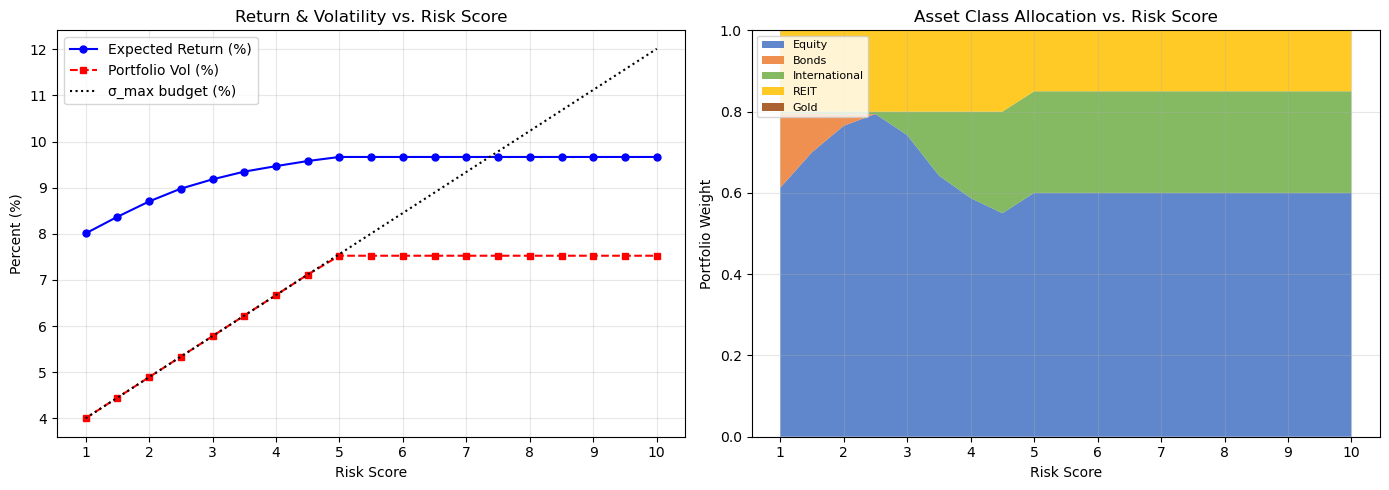


Risk Score Sweep — Key Metrics:
  RS  Return (%)  Vol (%)  Equity  Bonds  International
 1.0       8.007    4.000   0.613  0.183          0.004
 1.5       8.367    4.445   0.700  0.095          0.005
 2.0       8.700    4.890   0.765  0.027          0.008
 2.5       8.978    5.335   0.794  0.000          0.006
 3.0       9.180    5.780   0.742  0.000          0.058
 3.5       9.347    6.225   0.643  0.000          0.157
 4.0       9.466    6.670   0.587  0.000          0.213
 4.5       9.577    7.115   0.550  0.000          0.250
 5.0       9.665    7.524   0.600  0.000          0.250
 5.5       9.665    7.524   0.600  0.000          0.250
 6.0       9.665    7.524   0.600  0.000          0.250
 6.5       9.665    7.524   0.600  0.000          0.250
 7.0       9.665    7.524   0.600  0.000          0.250
 7.5       9.665    7.524   0.600  0.000          0.250
 8.0       9.665    7.524   0.600  0.000          0.250
 8.5       9.665    7.524   0.600  0.000          0.250
 9.0       9.66

In [103]:
rs_values  = np.arange(1.0, 10.5, 0.5)
sweep_rows = []

for rs in rs_values:
    s_max = sigma_max(rs)
    w     = cp.Variable(N_ASSETS)
    prob  = cp.Problem(
        cp.Minimize(cp.quad_form(w, Sigma) - 1.0 * (returns_vec @ w)),
        [cp.sum(w) == 1, w >= 0, w <= max_alloc_vec,
         cp.quad_form(w, Sigma) <= s_max ** 2]
    )
    prob.solve(solver=cp.CLARABEL)
    if w.value is None:
        continue

    wv  = w.value
    ret = float(returns_vec @ wv)
    vol = float(np.sqrt(max(float(cp.quad_form(w, Sigma).value), 0.0)))

    sweep_rows.append({
        'RS':             rs,
        'Return (%)':     ret * 100,
        'Vol (%)':        vol * 100,
        'σ_max (%)':      s_max * 100,
        'Equity':         sum(float(wv[ASSET_ORDER.index(a)]) for a in ['S001','S002','S003','S004','S005']),
        'Bonds':          sum(float(wv[ASSET_ORDER.index(a)]) for a in ['B001','B002']),
        'International':  sum(float(wv[ASSET_ORDER.index(a)]) for a in ['I001','I002']),
        'REIT':           float(wv[ASSET_ORDER.index('R001')]),
        'Gold':           float(wv[ASSET_ORDER.index('C001')]),
    })

sweep_df = pd.DataFrame(sweep_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — return & vol vs risk score
ax = axes[0]
ax.plot(sweep_df['RS'], sweep_df['Return (%)'], 'b-o', markersize=5, label='Expected Return (%)')
ax.plot(sweep_df['RS'], sweep_df['Vol (%)'],    'r--s', markersize=5, label='Portfolio Vol (%)')
ax.plot(sweep_df['RS'], sweep_df['σ_max (%)'],  'k:',  linewidth=1.5, label='σ_max budget (%)')
ax.set_xlabel('Risk Score')
ax.set_ylabel('Percent (%)')
ax.set_title('Return & Volatility vs. Risk Score')
ax.legend()
ax.set_xticks(range(1, 11))
ax.grid(alpha=0.3)

# Right — stacked asset class allocation
ax2 = axes[1]
classes = ['Equity', 'Bonds', 'International', 'REIT', 'Gold']
colors  = ['#4472C4', '#ED7D31', '#70AD47', '#FFC000', '#9E480E']
ax2.stackplot(sweep_df['RS'], [sweep_df[c] for c in classes],
              labels=classes, colors=colors, alpha=0.85)
ax2.set_xlabel('Risk Score')
ax2.set_ylabel('Portfolio Weight')
ax2.set_title('Asset Class Allocation vs. Risk Score')
ax2.legend(loc='upper left', fontsize=8)
ax2.set_xticks(range(1, 11))
ax2.set_ylim(0, 1)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR + 'sensitivity_risk_score_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRisk Score Sweep — Key Metrics:')
print(sweep_df[['RS','Return (%)','Vol (%)','Equity','Bonds','International']].round(3).to_string(index=False))


**Key observations:**

**Risk-budget-limited regime (RS 1.0 → 4.5):**  
The portfolio's vol equals σ_max exactly — the optimizer has consumed every unit of risk allowance. It wants to hold more high-return assets but the risk ceiling stops it. The binding constraint is `w⊤Σw ≤ σ²_max`.

| RS | Return | Vol | σ_max | Bonds |
|---|---|---|---|---|
| 1.0 | 8.01% | 4.00% | 4.00% | 18.3% |
| 2.0 | 8.70% | 4.89% | 4.89% | 2.7% |
| 4.0 | 9.47% | 6.67% | 6.67% | 0% |

As RS increases, bonds are progressively swapped out for equities and international — the optimizer reclaims every extra unit of risk budget and converts it into return.

**Kink point at RS≈5:**  
The transition where the binding constraint switches from the risk budget to asset caps. By RS=5, σ_max = 7.56% and portfolio vol = 7.52% — the optimizer has maxed out all high-return assets under their caps before reaching the risk ceiling.

**Cap-limited regime (RS 5.0 → 10.0):**  
The portfolio's vol is below σ_max — the risk budget has slack. The optimizer has already maxed out every high-return asset at its allocation cap and has nowhere left to go. The binding constraints are `w ≤ caps`.

| RS | Return | Vol | σ_max | Gap |
|---|---|---|---|---|
| 5.0 | 9.665% | 7.52% | 7.56% | 0.04% |
| 7.0 | 9.665% | 7.52% | 9.34% | 1.82% |
| 10.0 | 9.665% | 7.52% | 12.01% | 4.49% |

Return and vol are completely frozen across all 12 rows — giving the client more risk tolerance does nothing because asset caps, not the risk budget, are the binding constraint. This is the same result the LP produces, consistent with Section 6.3.

**One-line summary:** risk-budget-limited means the *ceiling is too low*. Cap-limited means the *assets ran out first*.


### 12.3 ESG Comparison at the Same Risk Score

We fix **RS=7** and solve the QP three times — once per ESG tier:
- **Low ESG** — no ESG constraint (full 11-asset universe)
- **Medium ESG** — weighted ESG ≥ 68
- **High ESG** — weighted ESG ≥ 75

**Why RS=7?** Two reasons:
1. RS=7 is in the cap-limited zone (above the RS≈5 kink from Section 12.2), meaning the optimizer is actively chasing high-return assets like Apple (ESG=65) and JPMorgan (ESG=58). The ESG constraint has a visible, observable effect on composition here — at lower RS the portfolio is already bond-heavy and naturally scores high ESG, so the constraint would change little.
2. RS=7 is the project guide's stated threshold where Apple first becomes appropriate. It is the lowest RS where Apple enters the portfolio under Low ESG, making it the most meaningful boundary to demonstrate ESG exclusion.


In [104]:
esg_configs = [
    ('Low ESG',    0,  'no ESG constraint'),
    ('Medium ESG', 68, 'weighted ESG ≥ 68'),
    ('High ESG',   75, 'weighted ESG ≥ 75'),
]

rs_fixed    = 7
s_max_fixed = sigma_max(rs_fixed)
print(f'Risk Score {rs_fixed} | σ_max = {s_max_fixed*100:.2f}%')
print('='*60)

esg_results = {}
for label, esg_thresh, desc in esg_configs:
    w = cp.Variable(N_ASSETS)
    constraints = [
        cp.sum(w) == 1, w >= 0, w <= max_alloc_vec,
        cp.quad_form(w, Sigma) <= s_max_fixed ** 2,
    ]
    if esg_thresh > 0:
        constraints.append(esg_vec @ w >= esg_thresh)

    prob = cp.Problem(
        cp.Minimize(cp.quad_form(w, Sigma) - 1.0 * (returns_vec @ w)),
        constraints
    )
    prob.solve(solver=cp.CLARABEL)

    if w.value is None:
        print(f'  {label}: infeasible')
        continue

    wv  = w.value
    ret = float(returns_vec @ wv)
    vol = float(np.sqrt(max(float(cp.quad_form(w, Sigma).value), 0.0)))
    esg_actual = float(esg_vec @ wv)
    esg_results[label] = {'weights': wv, 'ret': ret, 'vol': vol, 'esg': esg_actual}

# Summary line per ESG tier
for label, res in esg_results.items():
    print(f'  {label:<12}: return={res["ret"]*100:.2f}%  vol={res["vol"]*100:.2f}%  ESG score={res["esg"]:.1f}')

# Weight comparison table
comp = {'Asset': [assets.loc[a, 'asset_name'] for a in ASSET_ORDER]}
for label, res in esg_results.items():
    comp[f'{label} (%)'] = [round(float(res['weights'][i]) * 100, 1) for i in range(N_ASSETS)]
comp_df = pd.DataFrame(comp).set_index('Asset')
display(comp_df[(comp_df > 0.5).any(axis=1)])

if 'Low ESG' in esg_results and 'High ESG' in esg_results:
    ret_cost = (esg_results['Low ESG']['ret'] - esg_results['High ESG']['ret']) * 100
    print(f'\n  Return cost (Low → High ESG): {ret_cost:.2f}% per year')


Risk Score 7 | σ_max = 9.34%
  Low ESG     : return=9.66%  vol=7.52%  ESG score=67.8
  Medium ESG  : return=9.66%  vol=7.48%  ESG score=68.0
  High ESG    : return=9.23%  vol=6.61%  ESG score=75.0


,Low ESG (%),Medium ESG (%),High ESG (%)
Asset,,,
Apple Inc.,20.0,20.0,7.0
Microsoft Corp.,20.0,20.0,20.0
Johnson & Johnson,0.0,0.0,20.0
JPMorgan Chase,20.0,17.9,0.0
US REIT Index,15.0,17.1,3.0
Emerging Markets,25.0,25.0,25.0
Developed Markets,0.0,0.0,25.0



  Return cost (Low → High ESG): 0.44% per year


**Key observations:**

- **Low ESG holds Apple and JPMorgan freely**: With no ESG constraint, the optimizer maxes out the highest-return assets including Apple (ESG=65) and JPMorgan (ESG=58), both of which fall below the High ESG threshold of 75.
- **High ESG heavily constrains Apple and fully excludes JPMorgan**: JPMorgan (ESG=58) is excluded entirely. Apple (ESG=65) is reduced to 7% — including more would force the remaining portfolio to average above ESG=77.5 to maintain the ≥75 threshold, leaving too little room for other assets. The optimizer substitutes with higher-ESG assets (J&J ESG=81, Developed Markets ESG=78, Treasuries ESG=90).
- **Medium ESG is a partial restriction**: ESG ≥ 68 reduces JPMorgan (ESG=58) to 17.9% — it is not fully excluded, but the weighted ESG constraint limits how much low-scoring assets can be held. Apple (ESG=65) is retained at its full 20% cap. The composition sits between the Low and High ESG extremes.
- **The return cost is quantified**: The annual return penalty of adopting High vs Low ESG is reported above — a concrete number Apex Capital can present to clients when discussing ESG preference.
- **Composition changes are observable**: The weight table shows materially different holdings across tiers, not marginal tilts — confirming RS=7 was the right choice to demonstrate the ESG effect.
